In [ ]:
# ── Instalasi ─────────────────────────────────────────────────
!pip install wordcloud gensim transformers torch -q

# ── Standard Library ──────────────────────────────────────────
import os, re, json, warnings
warnings.filterwarnings('ignore')

# ── Data Manipulation ─────────────────────────────────────────
import numpy as np
import pandas as pd

# ── NLP ───────────────────────────────────────────────────────
import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from nltk.tokenize import word_tokenize
nltk.download('stopwords', quiet=True)
nltk.download('punkt',     quiet=True)
nltk.download('punkt_tab', quiet=True)

# ── Feature Extraction ────────────────────────────────────────
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

# ── Word2Vec ──────────────────────────────────────────────────
from gensim.models import Word2Vec

# ── Transformer / IndoBERT ────────────────────────────────────
from transformers import AutoTokenizer, AutoModel
import torch

# ── Modeling ──────────────────────────────────────────────────
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.naive_bayes import MultinomialNB, GaussianNB
from sklearn.tree import DecisionTreeClassifier, plot_tree

# ── Evaluasi ──────────────────────────────────────────────────
from sklearn.metrics import (
    confusion_matrix, classification_report,
    accuracy_score, precision_score, recall_score, f1_score, precision_recall_fscore_support
)

# ── Visualisasi ───────────────────────────────────────────────
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 100

print('✅ Semua library berhasil diimpor.')


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 57.3 MB/s eta 0:00:00
✅ Semua library berhasil diimpor.


In [ ]:
FILE_NAME = 'final_dataset.csv'

if not os.path.exists(FILE_NAME):
    raise FileNotFoundError(
        f"File '{FILE_NAME}' tidak ditemukan. "
        "Silakan upload file ke Colab terlebih dahulu."
    )

df     = pd.read_csv(FILE_NAME)
df_raw = df.copy()

print(f'✅ Data berhasil dimuat — {len(df)} baris, {df.shape[1]} kolom')
print(f'   Kolom : {list(df.columns)}')
df.head()


✅ Data berhasil dimuat — 270 baris, 2 kolom
   Kolom : ['news_title', 'target']


,news_title,target
0,"Over a pint in Oxford, we may have stumbled up...",1
1,Idaho man reflects on family's pioneering lega...,1
2,The rise of sus­tainable soybeans: One farmer’...,1
3,U.S. Secretary of Agriculture visiting Central...,1
4,UPDATE: Lyon County identifies sulfur-based ag...,1


In [ ]:
print(f'Jumlah data SEBELUM cleaning : {len(df)}')
df = df.dropna(subset=['news_title', 'target'])
df = df.drop_duplicates(subset=['news_title'])
df = df.reset_index(drop=True)
print(f'Jumlah data SESUDAH cleaning  : {len(df)}')


Jumlah data SEBELUM cleaning : 270
Jumlah data SESUDAH cleaning  : 269


In [ ]:
stop_words = set(stopwords.words('english'))
stemmer    = PorterStemmer()

def clean_text(text: str) -> str:
    text  = text.lower()
    text  = re.sub(r'[^a-z\s]', '', text)
    words = [stemmer.stem(w) for w in text.split() if w not in stop_words]
    return ' '.join(words)

df['clean_text'] = df['news_title'].astype(str).apply(clean_text)
print('✅ Preprocessing selesai.')
df[['news_title', 'clean_text']].head()


✅ Preprocessing selesai.


,news_title,clean_text
0,"Over a pint in Oxford, we may have stumbled up...",pint oxford may stumbl upon holi grail agricul...
1,Idaho man reflects on family's pioneering lega...,idaho man reflect famili pioneer legaci aviat ...
2,The rise of sus­tainable soybeans: One farmer’...,rise sustain soybean one farmer vision reshap ...
3,U.S. Secretary of Agriculture visiting Central...,us secretari agricultur visit central georgia ...
4,UPDATE: Lyon County identifies sulfur-based ag...,updat lyon counti identifi sulfurbas agricultu...


In [ ]:
X_raw = df['clean_text']
y     = df['target']

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_raw, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Total data       : {len(df)}')
print(f'Data latih (80%) : {len(X_train_raw)}')
print(f'Data uji   (20%) : {len(X_test_raw)}')


Total data       : 269
Data latih (80%) : 215
Data uji   (20%) : 54


In [ ]:
# ── BoW ──────────────────────────────────────────────────────
vec_bow       = CountVectorizer()
X_train_bow   = vec_bow.fit_transform(X_train_raw)
X_test_bow    = vec_bow.transform(X_test_raw)
X_all_bow     = vec_bow.transform(X_raw)

# ── N-Gram (1,2) ─────────────────────────────────────────────
vec_ngram     = CountVectorizer(ngram_range=(1, 2))
X_train_ngram = vec_ngram.fit_transform(X_train_raw)
X_test_ngram  = vec_ngram.transform(X_test_raw)
X_all_ngram   = vec_ngram.transform(X_raw)

# ── TF-IDF ───────────────────────────────────────────────────
vec_tfidf     = TfidfVectorizer()
X_train_tfidf = vec_tfidf.fit_transform(X_train_raw)
X_test_tfidf  = vec_tfidf.transform(X_test_raw)
X_all_tfidf   = vec_tfidf.transform(X_raw)

print('✅ BoW, N-Gram, TF-IDF siap.')


✅ BoW, N-Gram, TF-IDF siap.


In [ ]:
VECTOR_SIZE = 100

def build_w2v_matrix(corpus_train, corpus_all):
    tokenized = [word_tokenize(d.lower()) for d in corpus_train]
    model     = Word2Vec(sentences=tokenized, vector_size=VECTOR_SIZE,
                         window=5, min_count=1, workers=4, seed=42)
    def doc_vec(doc):
        toks = word_tokenize(doc.lower())
        vecs = [model.wv[w] for w in toks if w in model.wv]
        return np.mean(vecs, axis=0) if vecs else np.zeros(VECTOR_SIZE)
    return model, np.array([doc_vec(d) for d in corpus_all])

model_w2v, X_all_w2v = build_w2v_matrix(X_train_raw.tolist(), X_raw.tolist())

# Align train/test indices
train_mask   = X_raw.index.isin(X_train_raw.index)
test_mask    = X_raw.index.isin(X_test_raw.index)
X_train_w2v  = X_all_w2v[train_mask]
X_test_w2v   = X_all_w2v[test_mask]

print(f'✅ Word2Vec — train: {X_train_w2v.shape}, test: {X_test_w2v.shape}')


✅ Word2Vec — train: (215, 100), test: (54, 100)


In [ ]:
MODEL_NAME = 'indobenchmark/indobert-base-p2'
print(f'⏳ Memuat IndoBERT: {MODEL_NAME}')

tokenizer_bert = AutoTokenizer.from_pretrained(MODEL_NAME)
model_bert_clf = AutoModel.from_pretrained(MODEL_NAME)
model_bert_clf.eval()

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model_bert_clf.to(device)
print(f'✅ IndoBERT dimuat — device: {device}')

def get_bert_embeddings(texts, batch_size=16):
    all_embeddings = []
    texts = list(texts)
    for start in range(0, len(texts), batch_size):
        batch   = texts[start:start + batch_size]
        encoded = tokenizer_bert(batch, padding=True, truncation=True,
                                 max_length=128, return_tensors='pt')
        encoded = {k: v.to(device) for k, v in encoded.items()}
        with torch.no_grad():
            outputs = model_bert_clf(**encoded)
        last_hidden = outputs.last_hidden_state
        mask        = encoded['attention_mask'].unsqueeze(-1).float()
        embeddings  = (last_hidden * mask).sum(1) / mask.sum(1).clamp(min=1e-9)
        all_embeddings.append(embeddings.cpu().numpy())
        print(f'  Batch {min(start+batch_size, len(texts))}/{len(texts)}', end='\r')
    print('\n✅ Embedding selesai.')
    return np.vstack(all_embeddings)

X_raw_reset = X_raw.reset_index(drop=True)
y_reset     = y.reset_index(drop=True)

X_bert_all   = get_bert_embeddings(X_raw_reset)
X_train_bert = X_bert_all[train_mask]
X_test_bert  = X_bert_all[test_mask]

print(f'Shape — all:{X_bert_all.shape}  train:{X_train_bert.shape}  test:{X_test_bert.shape}')


⏳ Memuat IndoBERT: indobenchmark/indobert-base-p2


config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json:   0%|          | 0.00/2.00 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/498M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/498M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

✅ IndoBERT dimuat — device: cpu
  Batch 269/269
✅ Embedding selesai.
Shape — all:(269, 768)  train:(215, 768)  test:(54, 768)


In [ ]:
# ============================================================
# FUNGSI HELPER — digunakan oleh semua skenario EXP-1 s/d EXP-10
# ============================================================

def print_split_header(exp_id, scenario):
    sep = '=' * 65
    print(f'\n{sep}')
    print(f'  Tabel 6: Evaluasi {exp_id} — {scenario} with Train-Test Split')
    print(f'{sep}')

def print_cv_header(exp_id, scenario):
    sep = '=' * 65
    print(f'\n{sep}')
    print(f'  Tabel 7: Evaluasi {exp_id} — {scenario} with Cross Validation')
    print(f'{sep}')

def print_classification_report(y_true, y_pred):
    print(classification_report(
        y_true, y_pred,
        target_names=['Berita Umum (0)', 'Berita Pertanian (1)'],
        digits=4
    ))

def plot_confusion_matrix(y_true, y_pred, exp_id, method, cmap='Blues'):
    cm = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap=cmap, cbar=False,
                xticklabels=['Berita Umum', 'Brt. Pertanian'],
                yticklabels=['Berita Umum', 'Brt. Pertanian'], ax=ax)
    ax.set_title(f'{exp_id} — Confusion Matrix ({method})',
                 fontsize=11, fontweight='bold', pad=10)
    ax.set_xlabel('Prediksi', fontsize=10)
    ax.set_ylabel('Aktual',   fontsize=10)
    plt.tight_layout()
    plt.show()
    plt.close()

def plot_decision_tree(model, feature_names, exp_id, scenario, method):
    plt.figure(figsize=(24, 10))
    plot_tree(model,
              feature_names=feature_names,
              class_names=['Umum', 'Pertanian'],
              filled=True, rounded=True,
              fontsize=8, max_depth=3)
    plt.title(f'Decision Tree — {exp_id}: {scenario} ({method})',
              fontsize=13, fontweight='bold', pad=18)
    plt.tight_layout()
    plt.show()
    plt.close()

def run_cv_full(X, y_cv, base_model, exp_id, scenario, feature_names=None, is_dt=False):
    """5-Fold CV: cetak tabel per fold + confusion matrix + (opsional) plot_tree."""
    skf   = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    score = cross_validate(
        base_model, X, y_cv, cv=skf,
        scoring=['accuracy', 'precision', 'recall', 'f1'],
        return_estimator=True
    )

    print_cv_header(exp_id, scenario)

    # Tabel per fold
    header = f'  {"Fold":<8} {"Accuracy":>10} {"Precision":>10} {"Recall":>10} {"F1-Score":>10}'
    sep50  = '  ' + '-' * 54
    print(header)
    print(sep50)
    for i in range(5):
        print(f'  Fold {i+1:<3} '
              f'{score["test_accuracy"][i]*100:>9.2f}% '
              f'{score["test_precision"][i]*100:>9.2f}% '
              f'{score["test_recall"][i]*100:>9.2f}% '
              f'{score["test_f1"][i]*100:>9.2f}%')
    print(sep50)
    print(f'  {"Mean":<8} '
          f'{score["test_accuracy"].mean()*100:>9.2f}% '
          f'{score["test_precision"].mean()*100:>9.2f}% '
          f'{score["test_recall"].mean()*100:>9.2f}% '
          f'{score["test_f1"].mean()*100:>9.2f}%')
    print(f'  {"Std":<8} '
          f'{score["test_accuracy"].std()*100:>9.2f}% '
          f'{score["test_precision"].std()*100:>9.2f}% '
          f'{score["test_recall"].std()*100:>9.2f}% '
          f'{score["test_f1"].std()*100:>9.2f}%')

    # Confusion matrix akumulasi seluruh fold
    y_pred_all = np.zeros(len(y_cv), dtype=int)
    for fold_model, (_, test_idx) in zip(score['estimator'],
                                          skf.split(X, y_cv)):
        if hasattr(X, 'toarray'):
            X_fold = X[test_idx]
        else:
            X_fold = X[test_idx]
        y_pred_all[test_idx] = fold_model.predict(X_fold)

    print('\n📊 Confusion Matrix (Akumulasi 5-Fold CV):')
    plot_confusion_matrix(y_cv, y_pred_all, exp_id, '5-Fold CV', cmap='Greens')

    # Plot decision tree dari fold terakhir
    if is_dt and feature_names is not None:
        last_model = score['estimator'][-1]
        plot_decision_tree(last_model, feature_names, exp_id, scenario, '5-Fold CV')

    return score

print('✅ Fungsi helper siap.')


✅ Fungsi helper siap.



  Tabel 6: Evaluasi EXP-1 — Bag of Words (BoW) + Decision Tree with Train-Test Split
                      precision    recall  f1-score   support

     Berita Umum (0)     1.0000    0.6957    0.8205        23
Berita Pertanian (1)     0.8158    1.0000    0.8986        31

            accuracy                         0.8704        54
           macro avg     0.9079    0.8478    0.8595        54
        weighted avg     0.8942    0.8704    0.8653        54



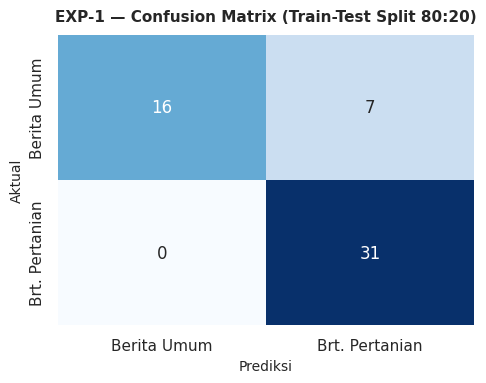

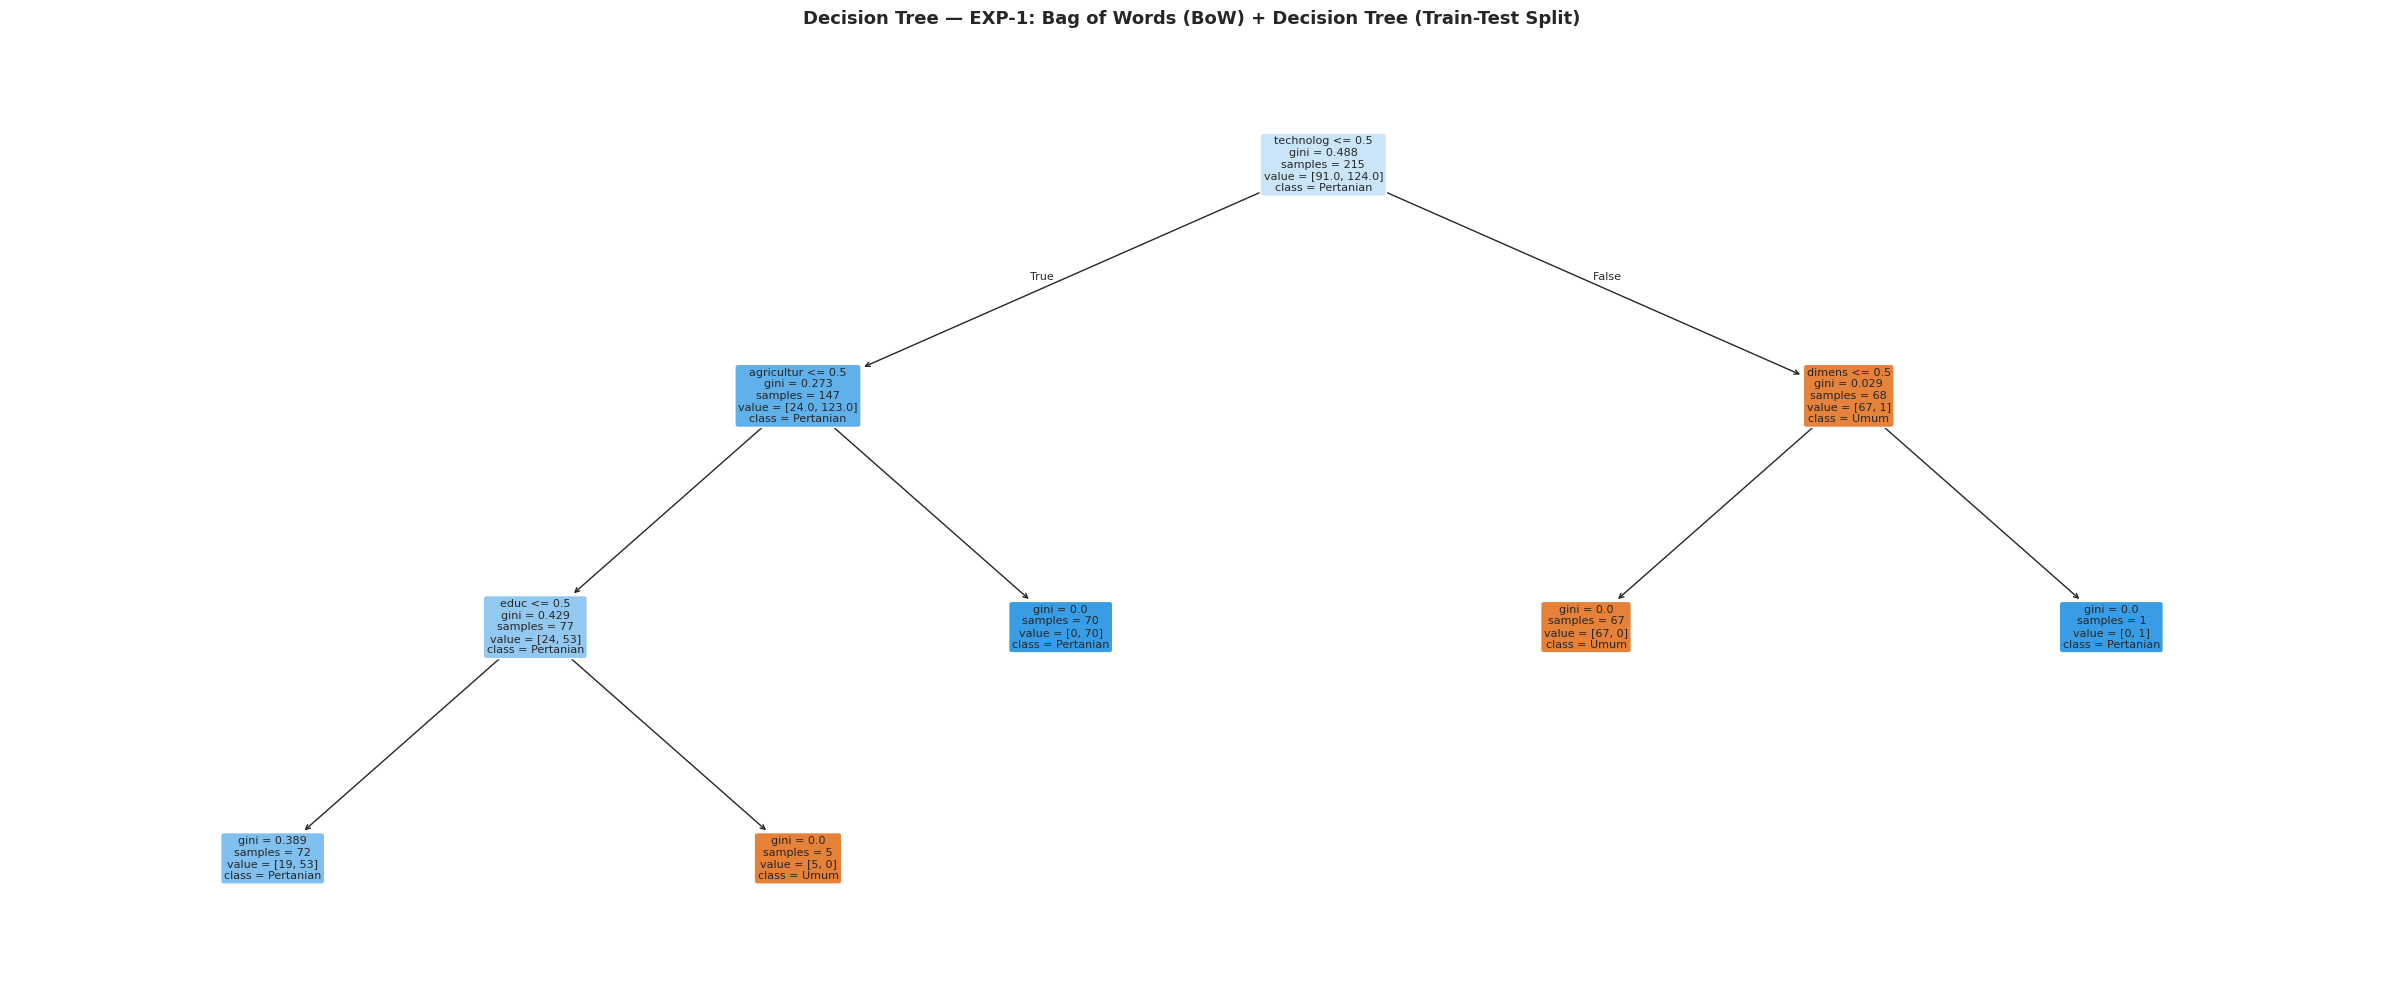


  Tabel 7: Evaluasi EXP-1 — Bag of Words (BoW) + Decision Tree with Cross Validation
  Fold       Accuracy  Precision     Recall   F1-Score
  ------------------------------------------------------
  Fold 1       88.89%     83.78%    100.00%     91.18%
  Fold 2       92.59%     88.57%    100.00%     93.94%
  Fold 3       88.89%     85.71%     96.77%     90.91%
  Fold 4       87.04%     83.33%     96.77%     89.55%
  Fold 5       84.91%     79.49%    100.00%     88.57%
  ------------------------------------------------------
  Mean         88.46%     84.18%     98.71%     90.83%
  Std           2.53%      2.98%      1.58%      1.82%

📊 Confusion Matrix (Akumulasi 5-Fold CV):


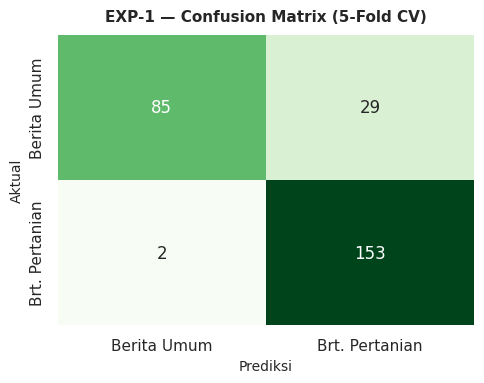

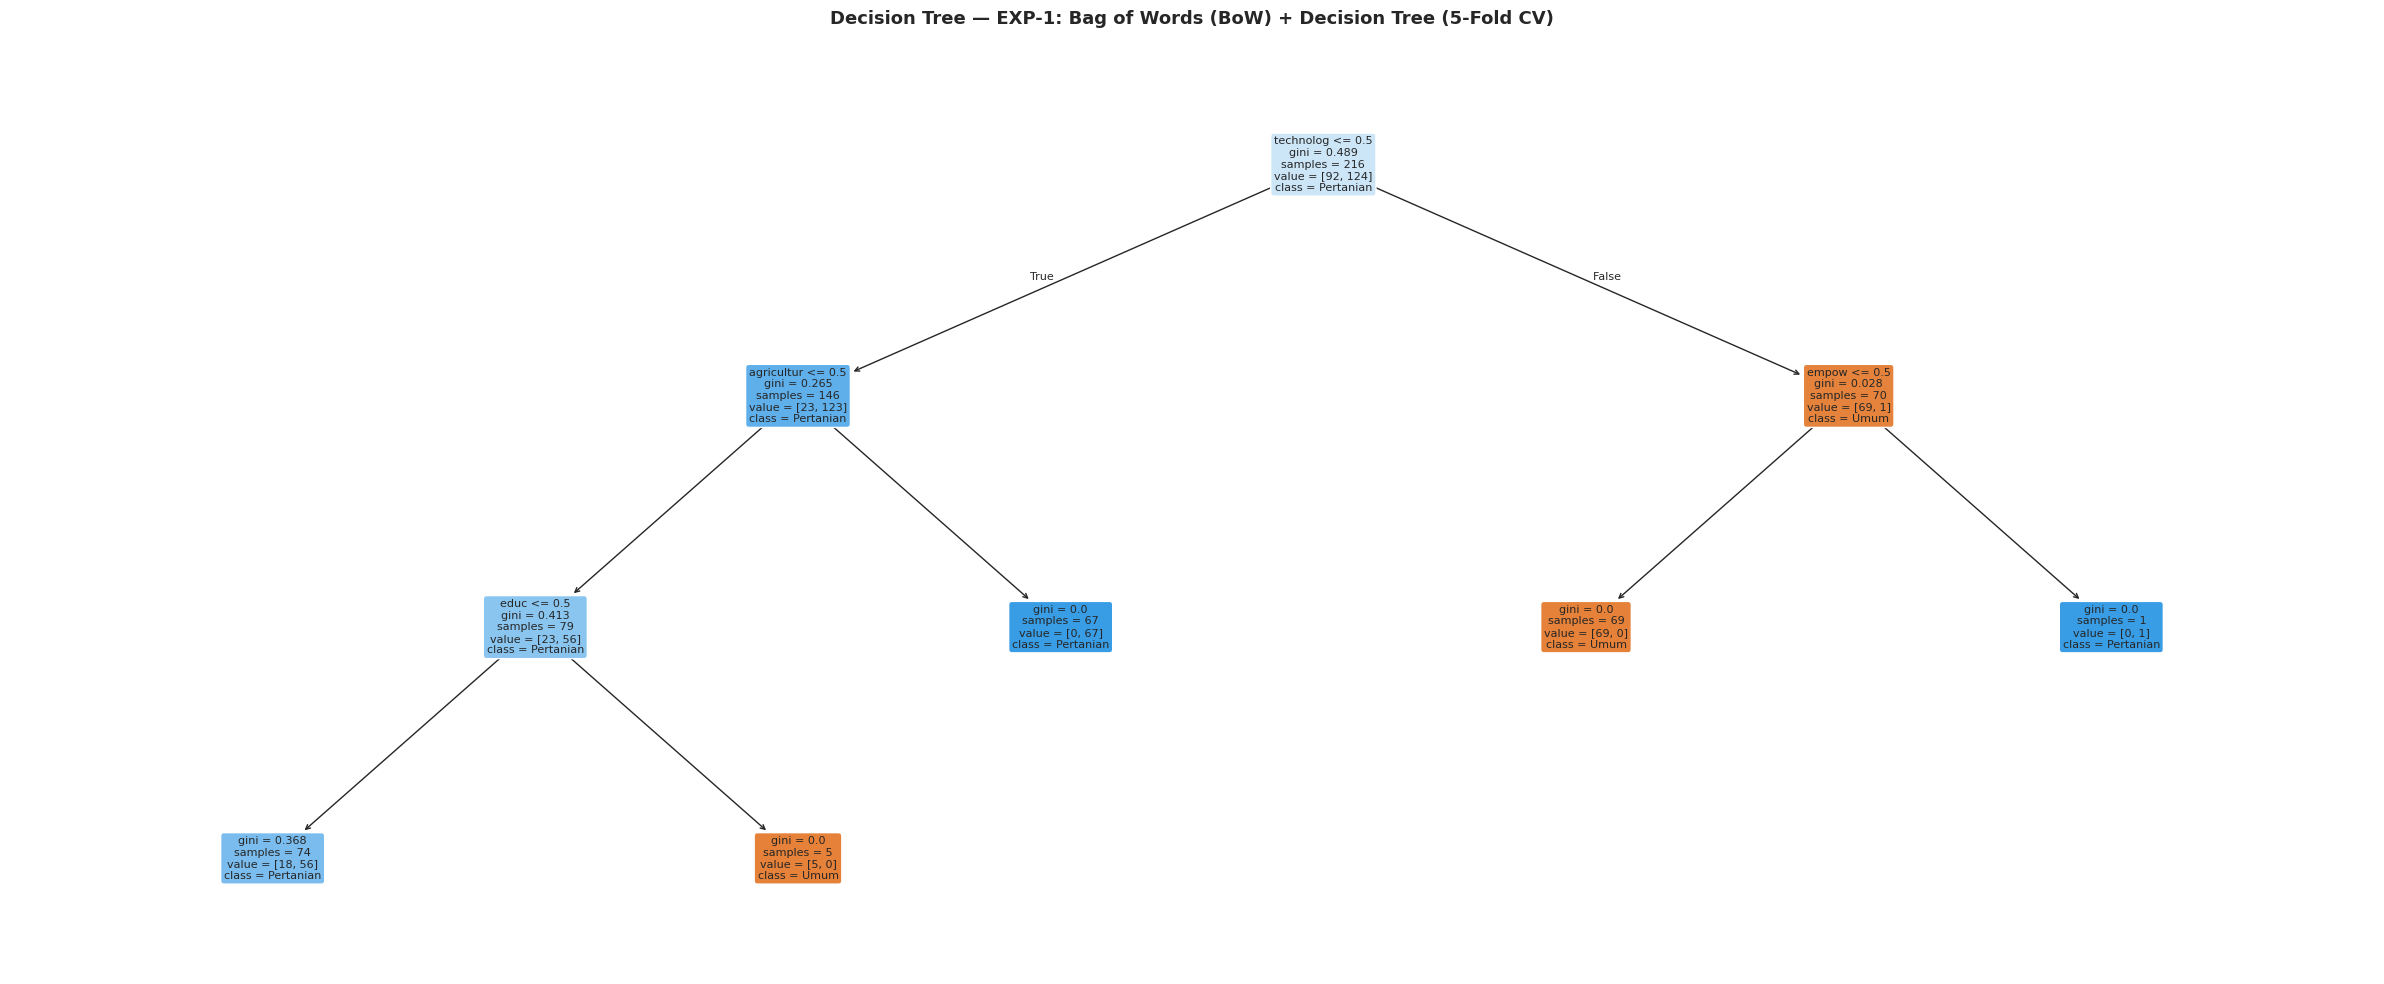

{'fit_time': array([0.01270843, 0.01163459, 0.00680017, 0.00641108, 0.00583291]),
 'score_time': array([0.02247405, 0.02219248, 0.01754332, 0.01623821, 0.01557684]),
 'estimator': [DecisionTreeClassifier(max_depth=3, random_state=42),
  DecisionTreeClassifier(max_depth=3, random_state=42),
  DecisionTreeClassifier(max_depth=3, random_state=42),
  DecisionTreeClassifier(max_depth=3, random_state=42),
  DecisionTreeClassifier(max_depth=3, random_state=42)],
 'test_accuracy': array([0.88888889, 0.92592593, 0.88888889, 0.87037037, 0.8490566 ]),
 'test_precision': array([0.83783784, 0.88571429, 0.85714286, 0.83333333, 0.79487179]),
 'test_recall': array([1.        , 1.        , 0.96774194, 0.96774194, 1.        ]),
 'test_f1': array([0.91176471, 0.93939394, 0.90909091, 0.89552239, 0.88571429])}

In [ ]:
# ============================================================
# EXP-1 : Bag of Words (BoW) + Decision Tree
# ============================================================
EXP_ID   = 'EXP-1'
SCENARIO = 'Bag of Words (BoW) + Decision Tree'

dt_bow = DecisionTreeClassifier(max_depth=3, random_state=42)
dt_bow.fit(X_train_bow, y_train)
y_pred_1 = dt_bow.predict(X_test_bow)

# ── Bagian A: Train-Test Split ────────────────────────────────
print_split_header(EXP_ID, SCENARIO)
print_classification_report(y_test, y_pred_1)
plot_confusion_matrix(y_test, y_pred_1, EXP_ID, 'Train-Test Split 80:20')
plot_decision_tree(dt_bow, vec_bow.get_feature_names_out(), EXP_ID, SCENARIO, 'Train-Test Split')

# ── Bagian B: 5-Fold Cross Validation ────────────────────────
run_cv_full(
    X_all_bow, y,
    DecisionTreeClassifier(max_depth=3, random_state=42),
    EXP_ID, SCENARIO,
    feature_names=vec_bow.get_feature_names_out(),
    is_dt=True
)



  Tabel 6: Evaluasi EXP-2 — Bag of Words (BoW) + Naive Bayes (Multinomial) with Train-Test Split
                      precision    recall  f1-score   support

     Berita Umum (0)     0.9524    0.8696    0.9091        23
Berita Pertanian (1)     0.9091    0.9677    0.9375        31

            accuracy                         0.9259        54
           macro avg     0.9307    0.9187    0.9233        54
        weighted avg     0.9275    0.9259    0.9254        54



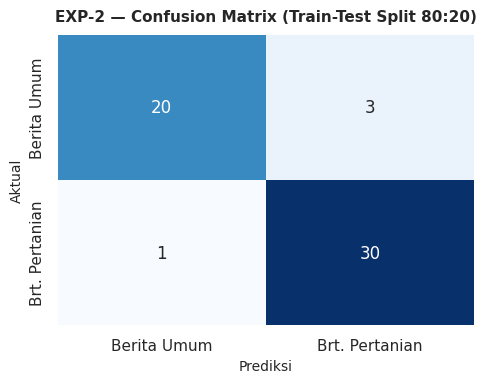


  Tabel 7: Evaluasi EXP-2 — Bag of Words (BoW) + Naive Bayes (Multinomial) with Cross Validation
  Fold       Accuracy  Precision     Recall   F1-Score
  ------------------------------------------------------
  Fold 1       90.74%     88.24%     96.77%     92.31%
  Fold 2       94.44%     91.18%    100.00%     95.38%
  Fold 3       94.44%     96.67%     93.55%     95.08%
  Fold 4       92.59%     90.91%     96.77%     93.75%
  Fold 5       88.68%     83.78%    100.00%     91.18%
  ------------------------------------------------------
  Mean         92.18%     90.15%     97.42%     93.54%
  Std           2.22%      4.20%      2.41%      1.61%

📊 Confusion Matrix (Akumulasi 5-Fold CV):


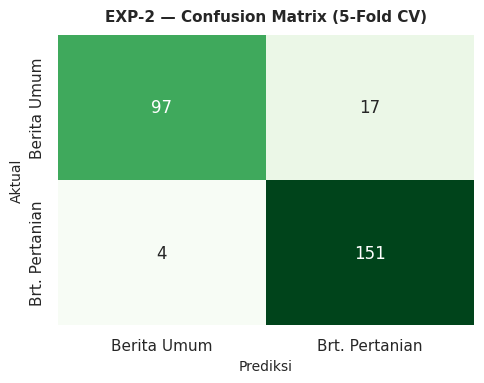

{'fit_time': array([0.00398088, 0.00260329, 0.00251985, 0.00366926, 0.00371361]),
 'score_time': array([0.01109648, 0.01043892, 0.01378703, 0.02378249, 0.01403165]),
 'estimator': [MultinomialNB(),
  MultinomialNB(),
  MultinomialNB(),
  MultinomialNB(),
  MultinomialNB()],
 'test_accuracy': array([0.90740741, 0.94444444, 0.94444444, 0.92592593, 0.88679245]),
 'test_precision': array([0.88235294, 0.91176471, 0.96666667, 0.90909091, 0.83783784]),
 'test_recall': array([0.96774194, 1.        , 0.93548387, 0.96774194, 1.        ]),
 'test_f1': array([0.92307692, 0.95384615, 0.95081967, 0.9375    , 0.91176471])}

In [ ]:
# ============================================================
# EXP-2 : Bag of Words (BoW) + Naive Bayes (Multinomial)
# ============================================================
EXP_ID   = 'EXP-2'
SCENARIO = 'Bag of Words (BoW) + Naive Bayes (Multinomial)'

nb_bow = MultinomialNB()
nb_bow.fit(X_train_bow, y_train)
y_pred_2 = nb_bow.predict(X_test_bow)

# ── Bagian A: Train-Test Split ────────────────────────────────
print_split_header(EXP_ID, SCENARIO)
print_classification_report(y_test, y_pred_2)
plot_confusion_matrix(y_test, y_pred_2, EXP_ID, 'Train-Test Split 80:20')

# ── Bagian B: 5-Fold Cross Validation ────────────────────────
run_cv_full(
    X_all_bow, y,
    MultinomialNB(),
    EXP_ID, SCENARIO,
    is_dt=False
)



  Tabel 6: Evaluasi EXP-3 — N-Gram (Bigram) + Decision Tree with Train-Test Split
                      precision    recall  f1-score   support

     Berita Umum (0)     1.0000    0.6957    0.8205        23
Berita Pertanian (1)     0.8158    1.0000    0.8986        31

            accuracy                         0.8704        54
           macro avg     0.9079    0.8478    0.8595        54
        weighted avg     0.8942    0.8704    0.8653        54



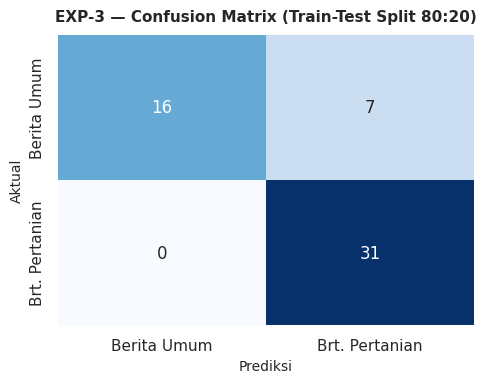

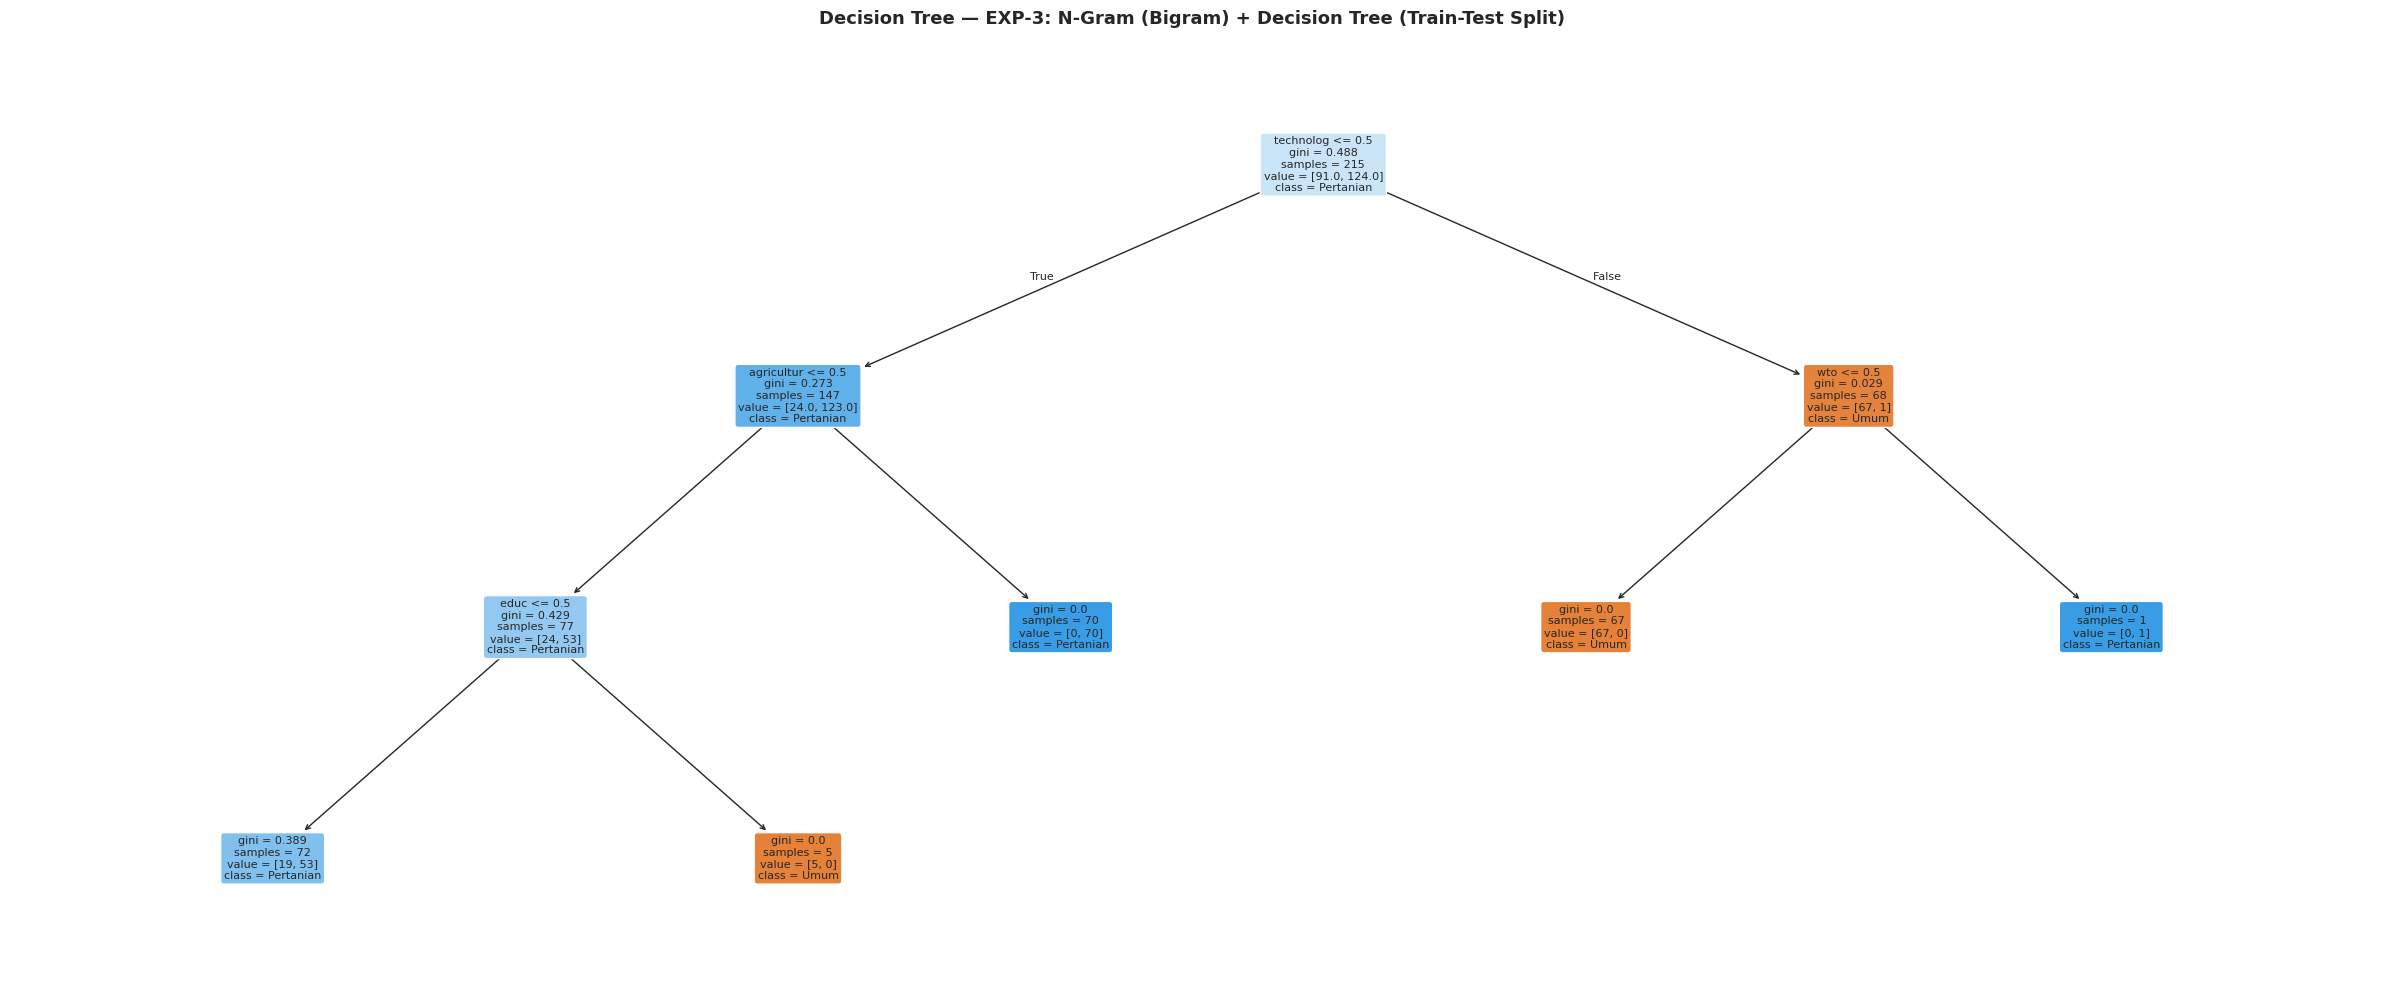


  Tabel 7: Evaluasi EXP-3 — N-Gram (Bigram) + Decision Tree with Cross Validation
  Fold       Accuracy  Precision     Recall   F1-Score
  ------------------------------------------------------
  Fold 1       88.89%     83.78%    100.00%     91.18%
  Fold 2       92.59%     88.57%    100.00%     93.94%
  Fold 3       88.89%     85.71%     96.77%     90.91%
  Fold 4       87.04%     83.33%     96.77%     89.55%
  Fold 5       84.91%     79.49%    100.00%     88.57%
  ------------------------------------------------------
  Mean         88.46%     84.18%     98.71%     90.83%
  Std           2.53%      2.98%      1.58%      1.82%

📊 Confusion Matrix (Akumulasi 5-Fold CV):


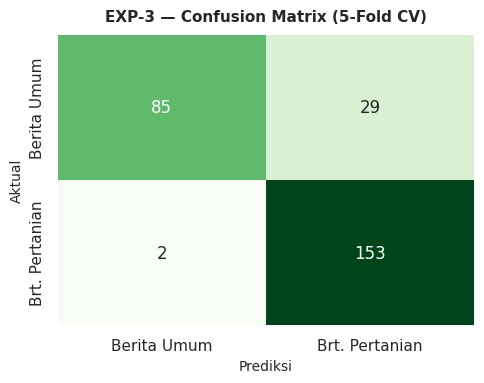

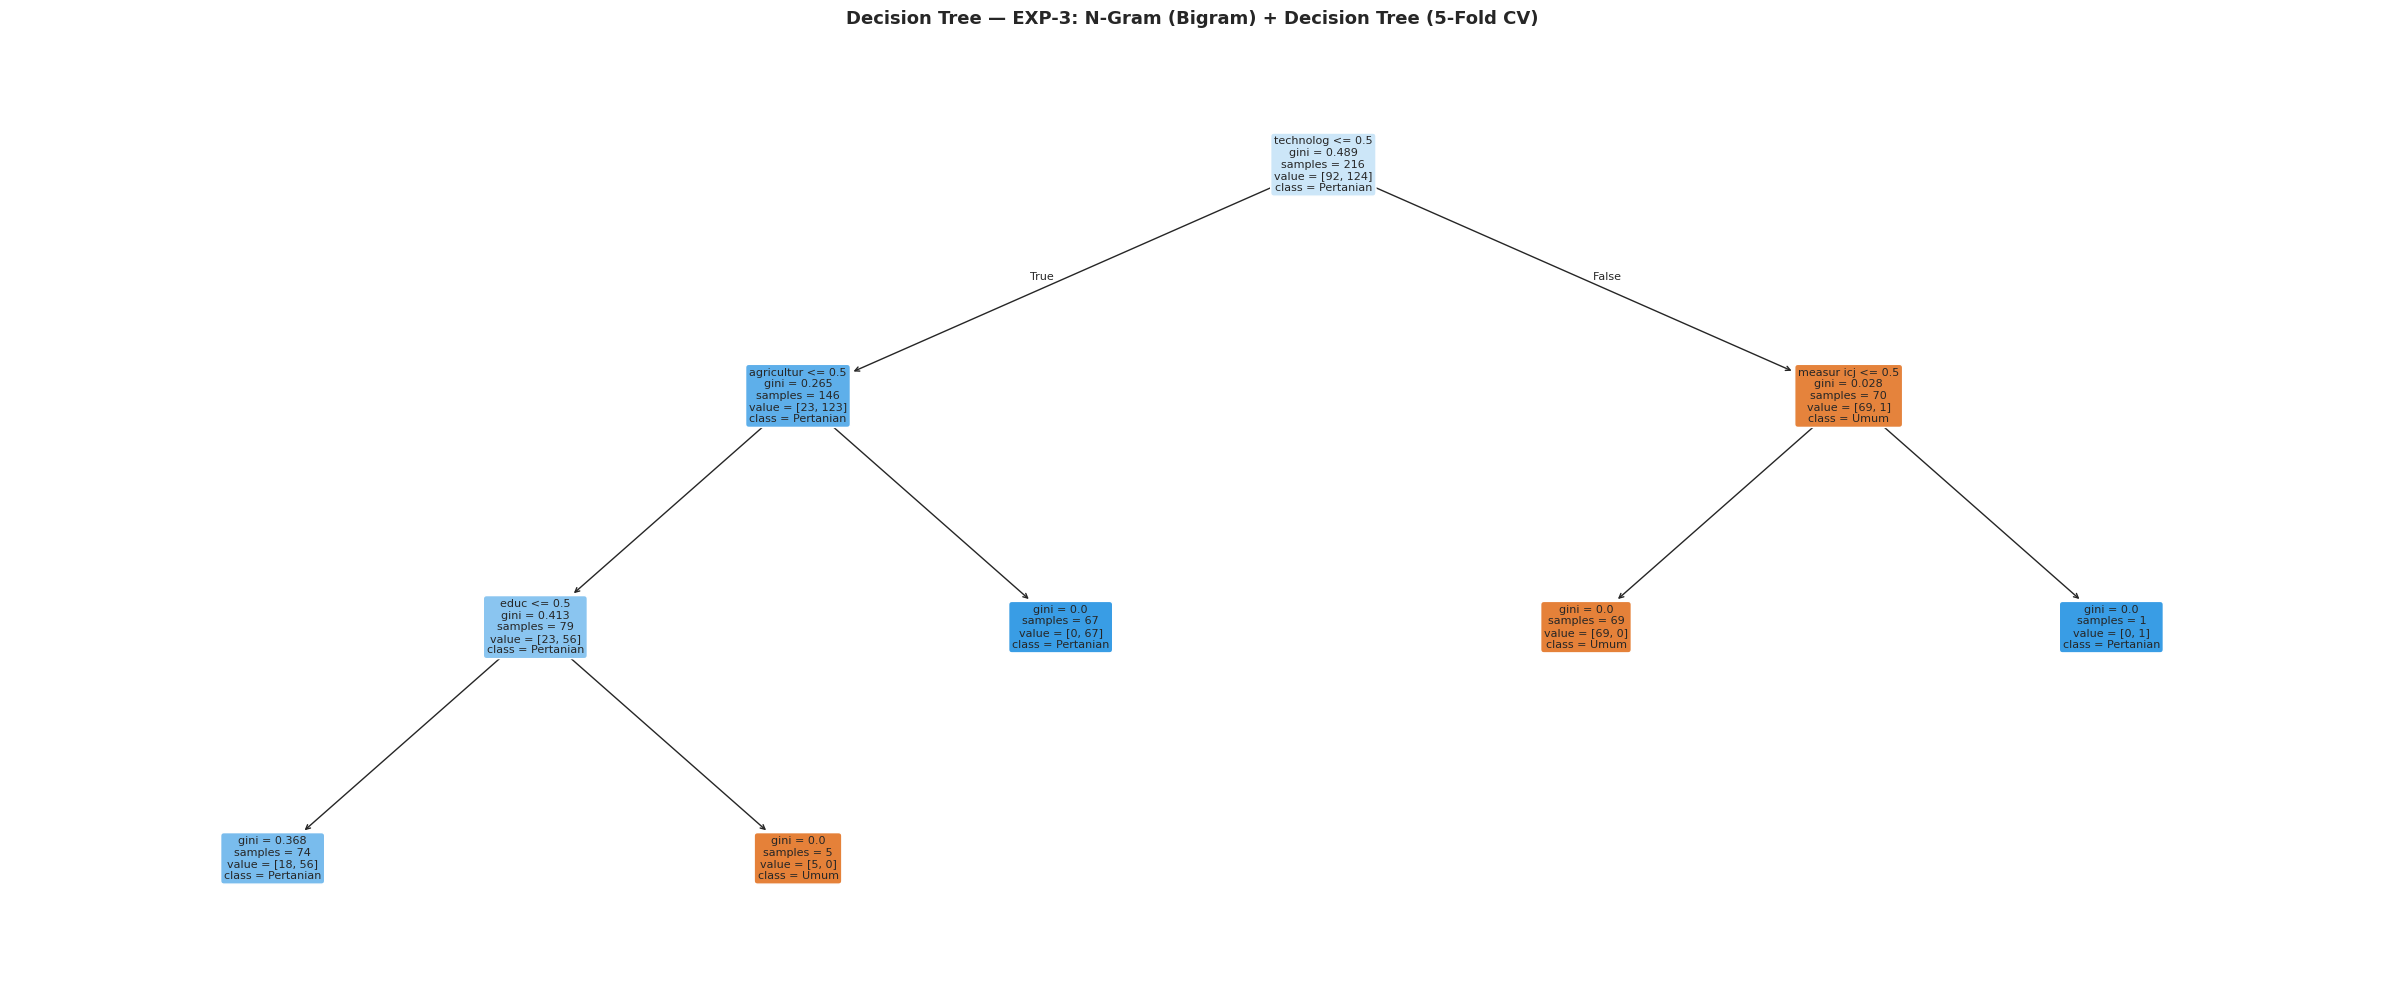

{'fit_time': array([0.01003265, 0.00754619, 0.00569987, 0.00654006, 0.00601602]),
 'score_time': array([0.01367807, 0.01142526, 0.01079965, 0.00978017, 0.01456547]),
 'estimator': [DecisionTreeClassifier(max_depth=3, random_state=42),
  DecisionTreeClassifier(max_depth=3, random_state=42),
  DecisionTreeClassifier(max_depth=3, random_state=42),
  DecisionTreeClassifier(max_depth=3, random_state=42),
  DecisionTreeClassifier(max_depth=3, random_state=42)],
 'test_accuracy': array([0.88888889, 0.92592593, 0.88888889, 0.87037037, 0.8490566 ]),
 'test_precision': array([0.83783784, 0.88571429, 0.85714286, 0.83333333, 0.79487179]),
 'test_recall': array([1.        , 1.        , 0.96774194, 0.96774194, 1.        ]),
 'test_f1': array([0.91176471, 0.93939394, 0.90909091, 0.89552239, 0.88571429])}

In [ ]:
# ============================================================
# EXP-3 : N-Gram + Decision Tree
# ============================================================
EXP_ID   = 'EXP-3'
SCENARIO = 'N-Gram (Bigram) + Decision Tree'

dt_ngram = DecisionTreeClassifier(max_depth=3, random_state=42)
dt_ngram.fit(X_train_ngram, y_train)
y_pred_3 = dt_ngram.predict(X_test_ngram)

# ── Bagian A: Train-Test Split ────────────────────────────────
print_split_header(EXP_ID, SCENARIO)
print_classification_report(y_test, y_pred_3)
plot_confusion_matrix(y_test, y_pred_3, EXP_ID, 'Train-Test Split 80:20')
plot_decision_tree(dt_ngram, vec_ngram.get_feature_names_out(), EXP_ID, SCENARIO, 'Train-Test Split')

# ── Bagian B: 5-Fold Cross Validation ────────────────────────
run_cv_full(
    X_all_ngram, y,
    DecisionTreeClassifier(max_depth=3, random_state=42),
    EXP_ID, SCENARIO,
    feature_names=vec_ngram.get_feature_names_out(),
    is_dt=True
)



  Tabel 6: Evaluasi EXP-4 — N-Gram (Bigram) + Naive Bayes (Multinomial) with Train-Test Split
                      precision    recall  f1-score   support

     Berita Umum (0)     0.9524    0.8696    0.9091        23
Berita Pertanian (1)     0.9091    0.9677    0.9375        31

            accuracy                         0.9259        54
           macro avg     0.9307    0.9187    0.9233        54
        weighted avg     0.9275    0.9259    0.9254        54



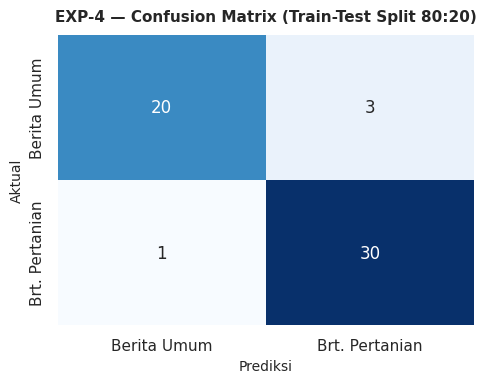


  Tabel 7: Evaluasi EXP-4 — N-Gram (Bigram) + Naive Bayes (Multinomial) with Cross Validation
  Fold       Accuracy  Precision     Recall   F1-Score
  ------------------------------------------------------
  Fold 1       90.74%     88.24%     96.77%     92.31%
  Fold 2       94.44%     91.18%    100.00%     95.38%
  Fold 3       94.44%     96.67%     93.55%     95.08%
  Fold 4       92.59%     90.91%     96.77%     93.75%
  Fold 5       88.68%     83.78%    100.00%     91.18%
  ------------------------------------------------------
  Mean         92.18%     90.15%     97.42%     93.54%
  Std           2.22%      4.20%      2.41%      1.61%

📊 Confusion Matrix (Akumulasi 5-Fold CV):


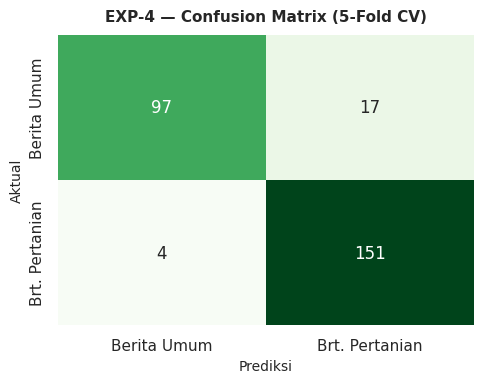

{'fit_time': array([0.02242708, 0.02133965, 0.01109934, 0.00683308, 0.02274203]),
 'score_time': array([0.03980255, 0.04089737, 0.03068686, 0.04576325, 0.09099197]),
 'estimator': [MultinomialNB(),
  MultinomialNB(),
  MultinomialNB(),
  MultinomialNB(),
  MultinomialNB()],
 'test_accuracy': array([0.90740741, 0.94444444, 0.94444444, 0.92592593, 0.88679245]),
 'test_precision': array([0.88235294, 0.91176471, 0.96666667, 0.90909091, 0.83783784]),
 'test_recall': array([0.96774194, 1.        , 0.93548387, 0.96774194, 1.        ]),
 'test_f1': array([0.92307692, 0.95384615, 0.95081967, 0.9375    , 0.91176471])}

In [ ]:
# ============================================================
# EXP-4 : N-Gram + Naive Bayes (Multinomial)
# ============================================================
EXP_ID   = 'EXP-4'
SCENARIO = 'N-Gram (Bigram) + Naive Bayes (Multinomial)'

nb_ngram = MultinomialNB()
nb_ngram.fit(X_train_ngram, y_train)
y_pred_4 = nb_ngram.predict(X_test_ngram)

# ── Bagian A: Train-Test Split ────────────────────────────────
print_split_header(EXP_ID, SCENARIO)
print_classification_report(y_test, y_pred_4)
plot_confusion_matrix(y_test, y_pred_4, EXP_ID, 'Train-Test Split 80:20')

# ── Bagian B: 5-Fold Cross Validation ────────────────────────
run_cv_full(
    X_all_ngram, y,
    MultinomialNB(),
    EXP_ID, SCENARIO,
    is_dt=False
)



  Tabel 6: Evaluasi EXP-5 — TF-IDF + Decision Tree with Train-Test Split
                      precision    recall  f1-score   support

     Berita Umum (0)     1.0000    0.6957    0.8205        23
Berita Pertanian (1)     0.8158    1.0000    0.8986        31

            accuracy                         0.8704        54
           macro avg     0.9079    0.8478    0.8595        54
        weighted avg     0.8942    0.8704    0.8653        54



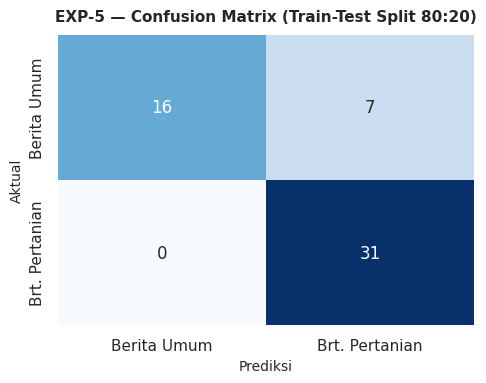

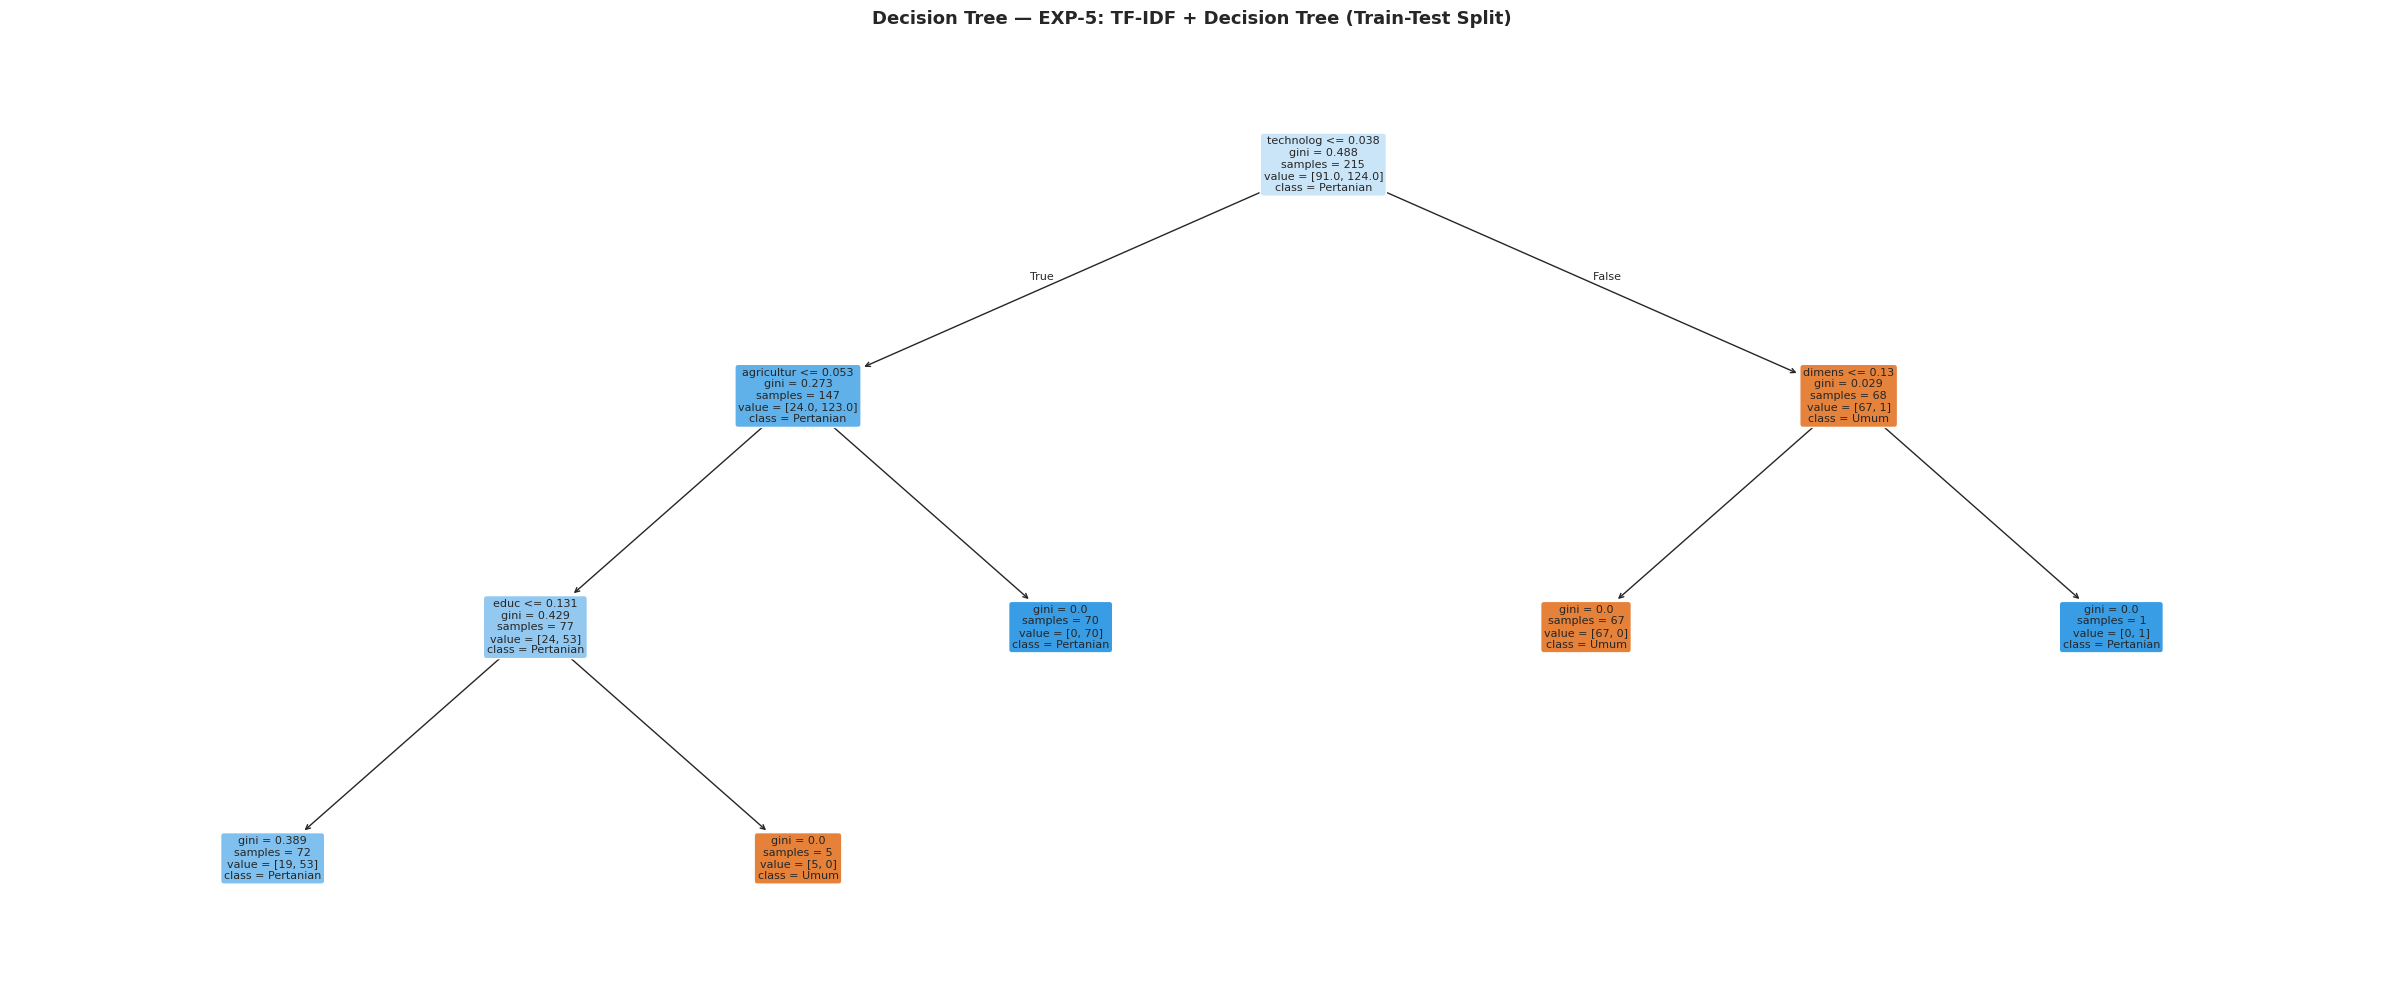


  Tabel 7: Evaluasi EXP-5 — TF-IDF + Decision Tree with Cross Validation
  Fold       Accuracy  Precision     Recall   F1-Score
  ------------------------------------------------------
  Fold 1       88.89%     83.78%    100.00%     91.18%
  Fold 2       92.59%     88.57%    100.00%     93.94%
  Fold 3       88.89%     85.71%     96.77%     90.91%
  Fold 4       87.04%     81.58%    100.00%     89.86%
  Fold 5       83.02%     77.50%    100.00%     87.32%
  ------------------------------------------------------
  Mean         88.09%     83.43%     99.35%     90.64%
  Std           3.11%      3.75%      1.29%      2.14%

📊 Confusion Matrix (Akumulasi 5-Fold CV):


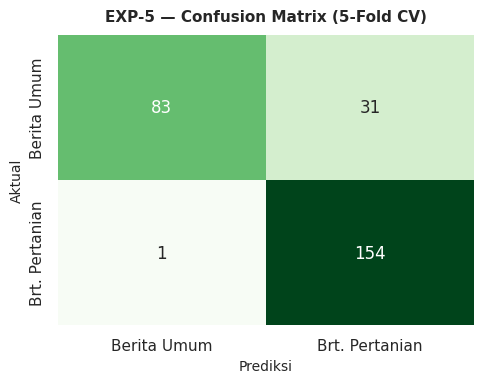

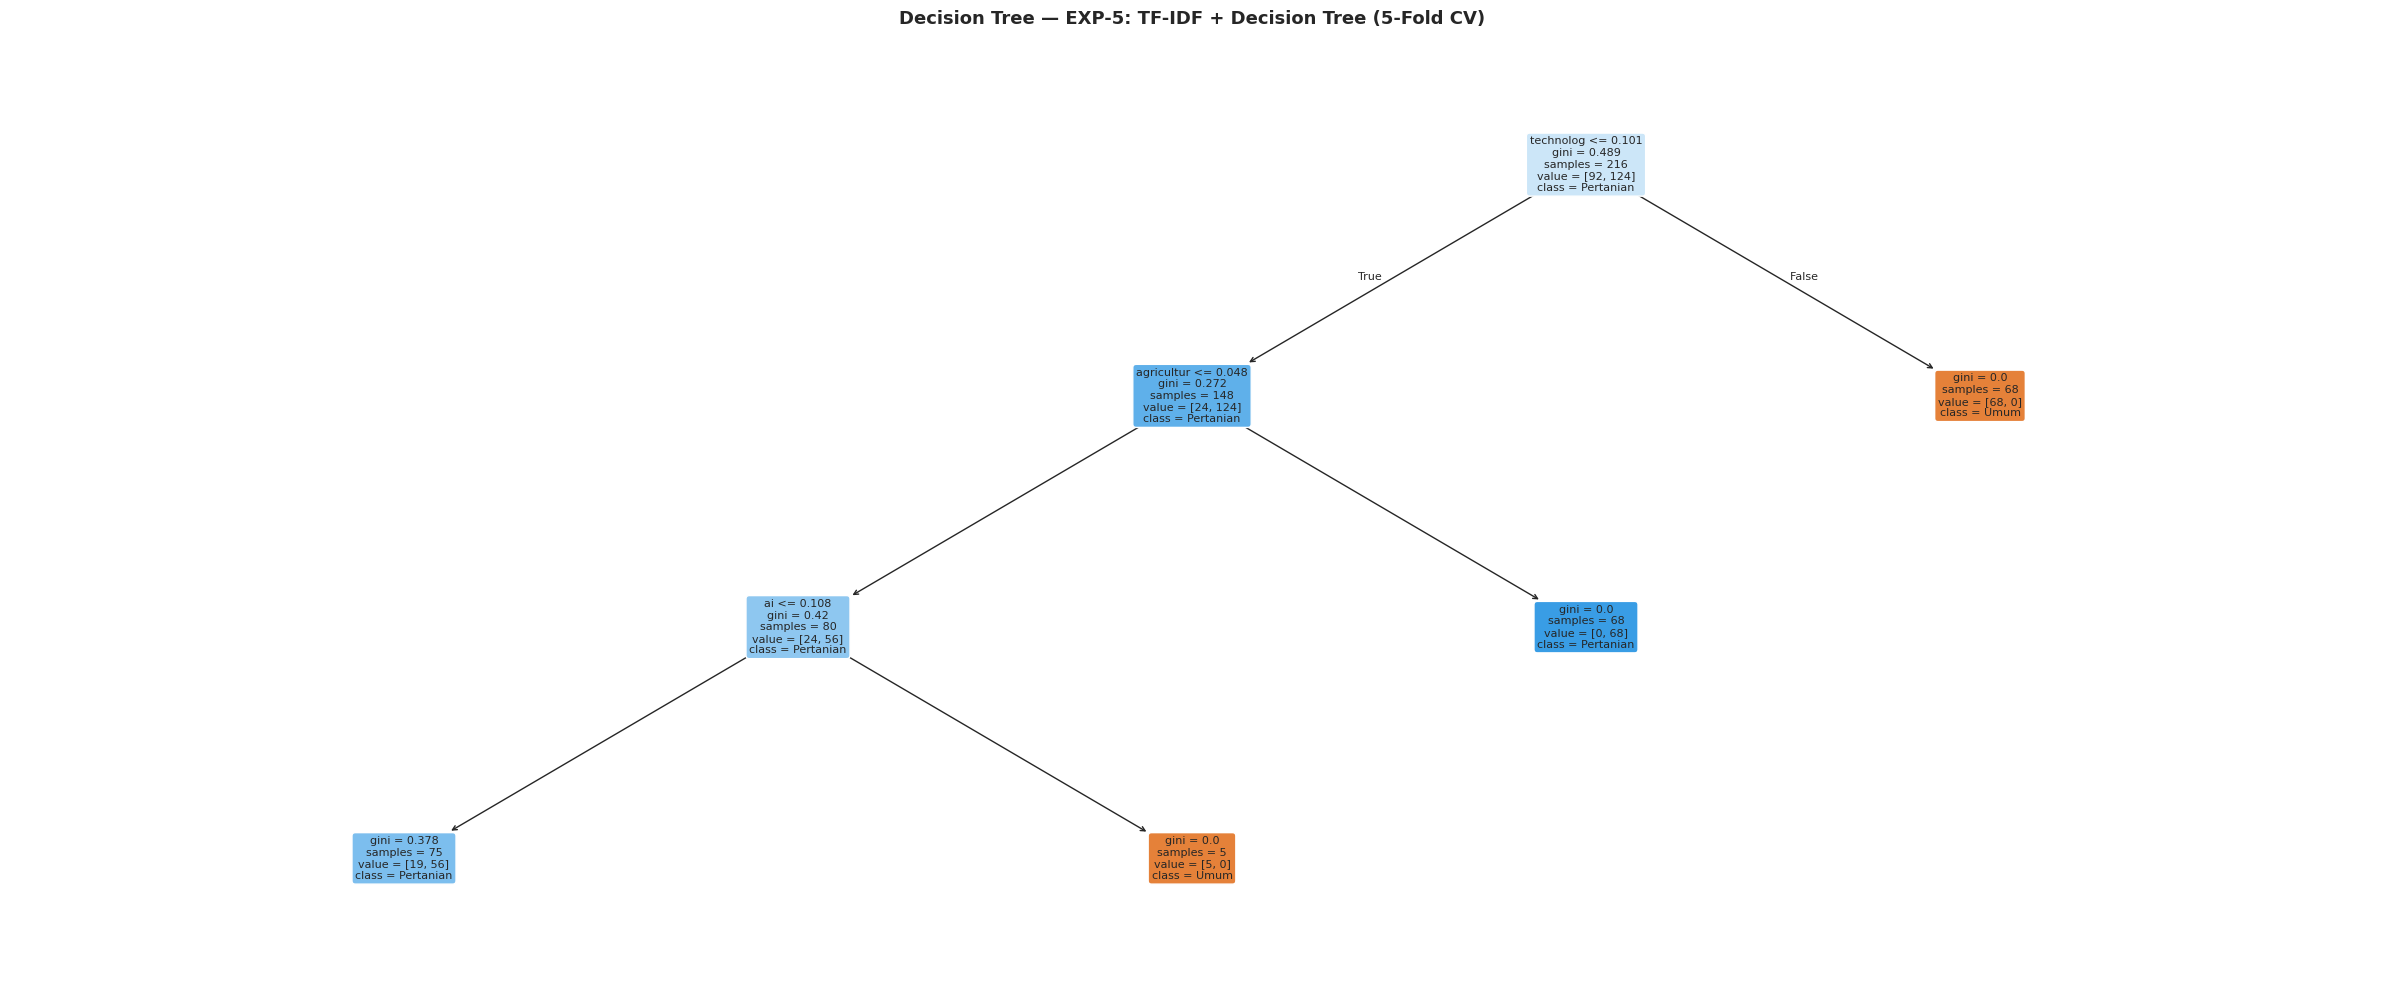

{'fit_time': array([0.02500582, 0.00639701, 0.006042  , 0.00585222, 0.00896168]),
 'score_time': array([0.01933503, 0.02063322, 0.01486301, 0.02228665, 0.01529503]),
 'estimator': [DecisionTreeClassifier(max_depth=3, random_state=42),
  DecisionTreeClassifier(max_depth=3, random_state=42),
  DecisionTreeClassifier(max_depth=3, random_state=42),
  DecisionTreeClassifier(max_depth=3, random_state=42),
  DecisionTreeClassifier(max_depth=3, random_state=42)],
 'test_accuracy': array([0.88888889, 0.92592593, 0.88888889, 0.87037037, 0.83018868]),
 'test_precision': array([0.83783784, 0.88571429, 0.85714286, 0.81578947, 0.775     ]),
 'test_recall': array([1.        , 1.        , 0.96774194, 1.        , 1.        ]),
 'test_f1': array([0.91176471, 0.93939394, 0.90909091, 0.89855072, 0.87323944])}

In [ ]:
# ============================================================
# EXP-5 : TF-IDF + Decision Tree
# ============================================================
EXP_ID   = 'EXP-5'
SCENARIO = 'TF-IDF + Decision Tree'

dt_tfidf = DecisionTreeClassifier(max_depth=3, random_state=42)
dt_tfidf.fit(X_train_tfidf, y_train)
y_pred_5 = dt_tfidf.predict(X_test_tfidf)

# ── Bagian A: Train-Test Split ────────────────────────────────
print_split_header(EXP_ID, SCENARIO)
print_classification_report(y_test, y_pred_5)
plot_confusion_matrix(y_test, y_pred_5, EXP_ID, 'Train-Test Split 80:20')
plot_decision_tree(dt_tfidf, vec_tfidf.get_feature_names_out(), EXP_ID, SCENARIO, 'Train-Test Split')

# ── Bagian B: 5-Fold Cross Validation ────────────────────────
run_cv_full(
    X_all_tfidf, y,
    DecisionTreeClassifier(max_depth=3, random_state=42),
    EXP_ID, SCENARIO,
    feature_names=vec_tfidf.get_feature_names_out(),
    is_dt=True
)



  Tabel 6: Evaluasi EXP-6 — TF-IDF + Naive Bayes (Multinomial) with Train-Test Split
                      precision    recall  f1-score   support

     Berita Umum (0)     0.9474    0.7826    0.8571        23
Berita Pertanian (1)     0.8571    0.9677    0.9091        31

            accuracy                         0.8889        54
           macro avg     0.9023    0.8752    0.8831        54
        weighted avg     0.8956    0.8889    0.8870        54



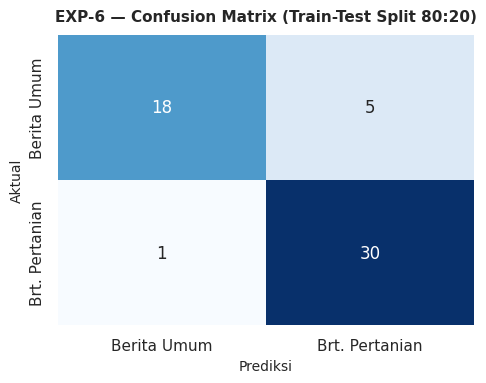


  Tabel 7: Evaluasi EXP-6 — TF-IDF + Naive Bayes (Multinomial) with Cross Validation
  Fold       Accuracy  Precision     Recall   F1-Score
  ------------------------------------------------------
  Fold 1       90.74%     88.24%     96.77%     92.31%
  Fold 2       92.59%     88.57%    100.00%     93.94%
  Fold 3       94.44%     91.18%    100.00%     95.38%
  Fold 4       85.19%     81.08%     96.77%     88.24%
  Fold 5       83.02%     77.50%    100.00%     87.32%
  ------------------------------------------------------
  Mean         89.20%     85.31%     98.71%     91.44%
  Std           4.38%      5.15%      1.58%      3.16%

📊 Confusion Matrix (Akumulasi 5-Fold CV):


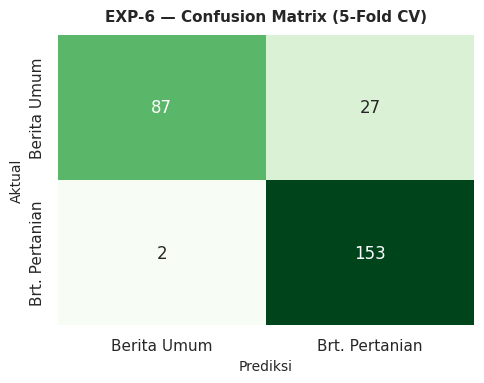

{'fit_time': array([0.0136075 , 0.00472331, 0.00363922, 0.00761509, 0.00353646]),
 'score_time': array([0.01752281, 0.01542044, 0.01366878, 0.0165565 , 0.02441454]),
 'estimator': [MultinomialNB(),
  MultinomialNB(),
  MultinomialNB(),
  MultinomialNB(),
  MultinomialNB()],
 'test_accuracy': array([0.90740741, 0.92592593, 0.94444444, 0.85185185, 0.83018868]),
 'test_precision': array([0.88235294, 0.88571429, 0.91176471, 0.81081081, 0.775     ]),
 'test_recall': array([0.96774194, 1.        , 1.        , 0.96774194, 1.        ]),
 'test_f1': array([0.92307692, 0.93939394, 0.95384615, 0.88235294, 0.87323944])}

In [ ]:
# ============================================================
# EXP-6 : TF-IDF + Naive Bayes (Multinomial)
# ============================================================
EXP_ID   = 'EXP-6'
SCENARIO = 'TF-IDF + Naive Bayes (Multinomial)'

nb_tfidf = MultinomialNB()
nb_tfidf.fit(X_train_tfidf, y_train)
y_pred_6 = nb_tfidf.predict(X_test_tfidf)

# ── Bagian A: Train-Test Split ────────────────────────────────
print_split_header(EXP_ID, SCENARIO)
print_classification_report(y_test, y_pred_6)
plot_confusion_matrix(y_test, y_pred_6, EXP_ID, 'Train-Test Split 80:20')

# ── Bagian B: 5-Fold Cross Validation ────────────────────────
run_cv_full(
    X_all_tfidf, y,
    MultinomialNB(),
    EXP_ID, SCENARIO,
    is_dt=False
)



  Tabel 6: Evaluasi EXP-7 — Word2Vec (dim=100) + Decision Tree with Train-Test Split
                      precision    recall  f1-score   support

     Berita Umum (0)     0.3077    0.3478    0.3265        23
Berita Pertanian (1)     0.4643    0.4194    0.4407        31

            accuracy                         0.3889        54
           macro avg     0.3860    0.3836    0.3836        54
        weighted avg     0.3976    0.3889    0.3921        54



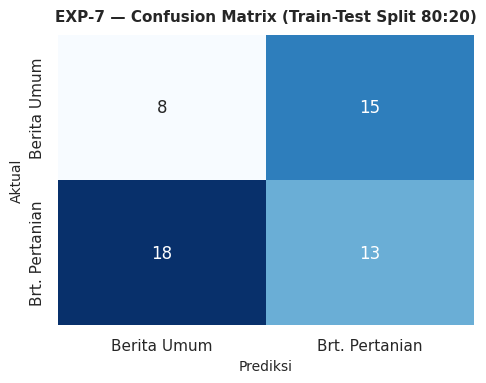

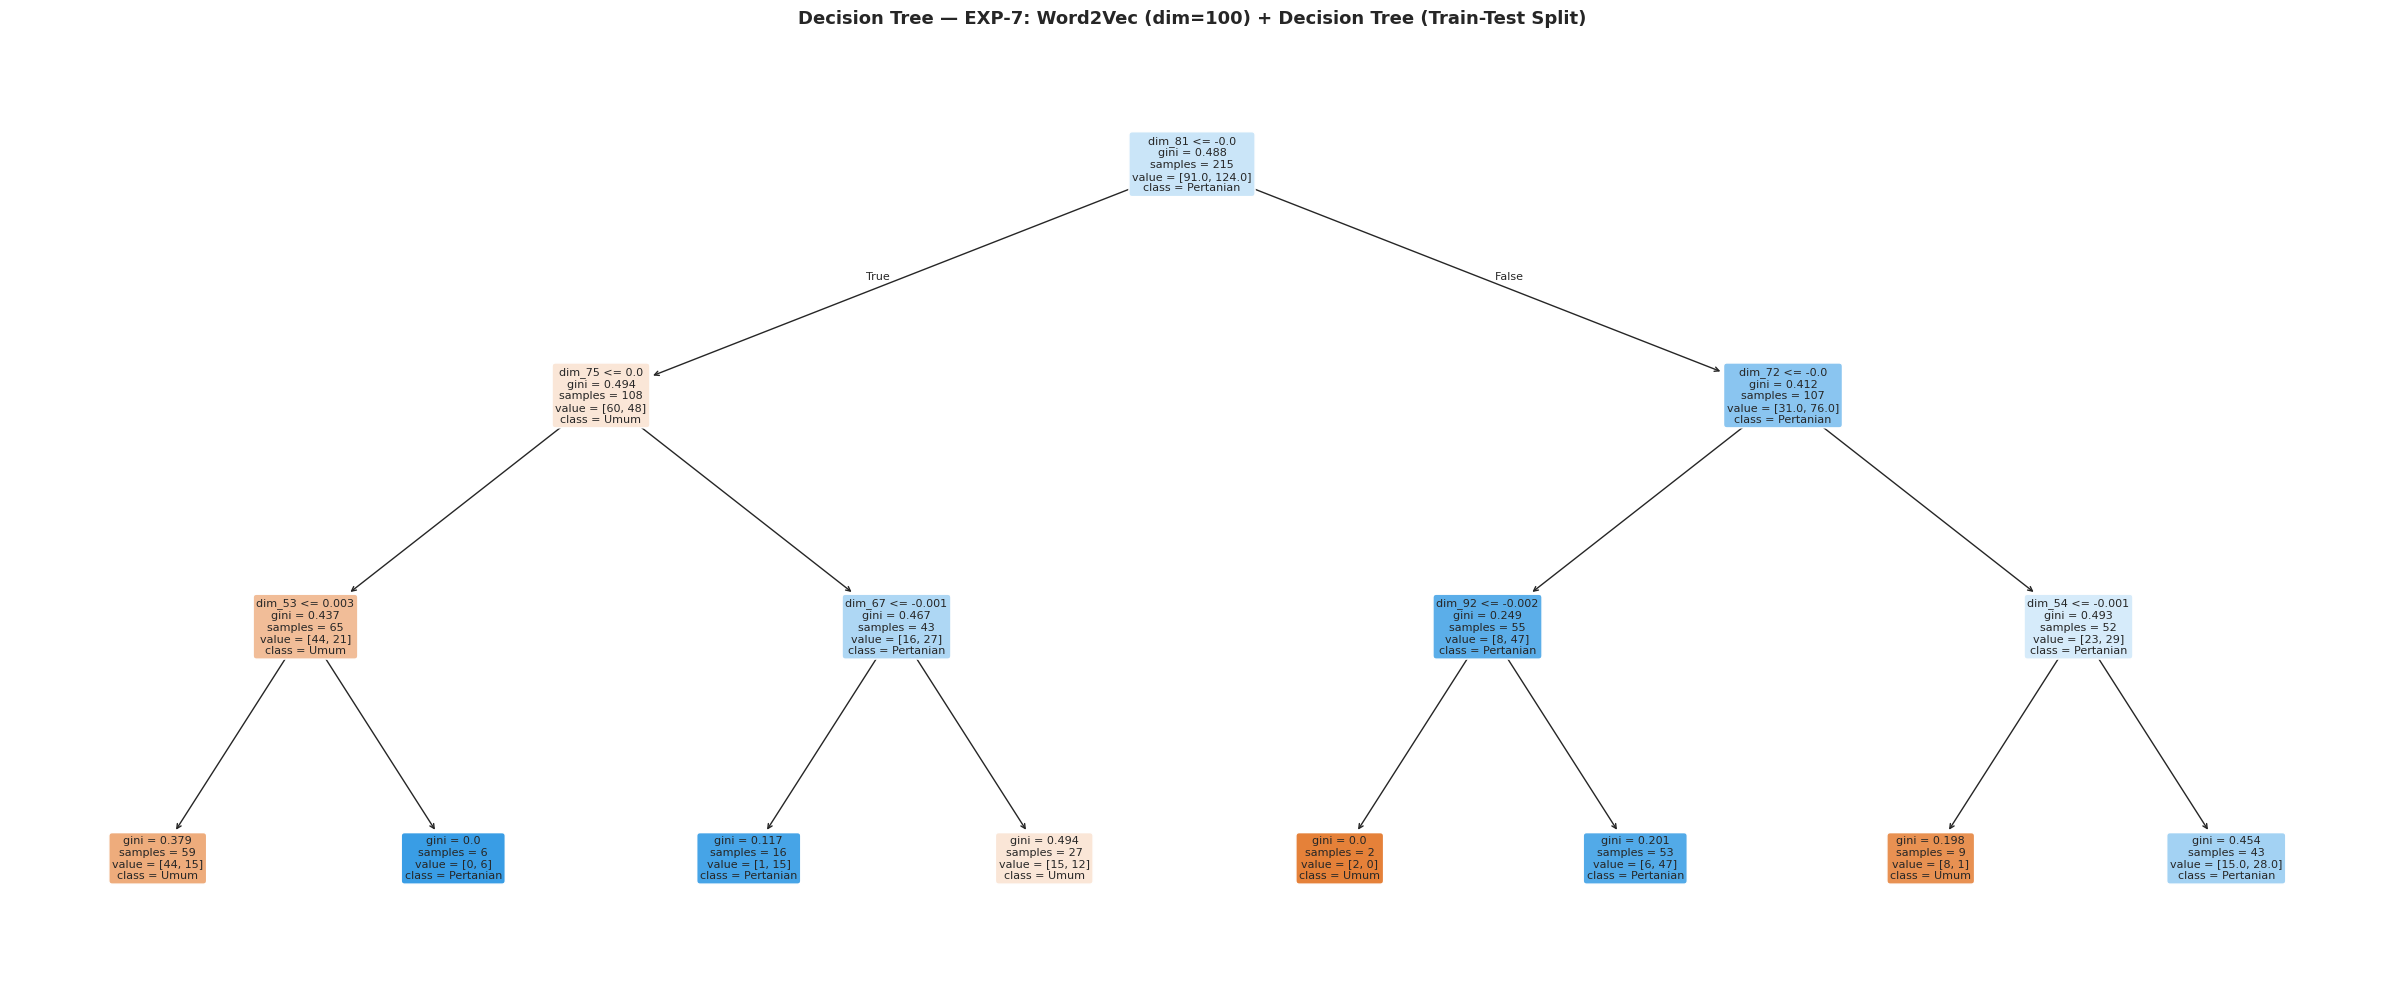


  Tabel 7: Evaluasi EXP-7 — Word2Vec (dim=100) + Decision Tree with Cross Validation
  Fold       Accuracy  Precision     Recall   F1-Score
  ------------------------------------------------------
  Fold 1       72.22%     75.00%     77.42%     76.19%
  Fold 2       68.52%     70.59%     77.42%     73.85%
  Fold 3       68.52%     81.82%     58.06%     67.92%
  Fold 4       72.22%     73.53%     80.65%     76.92%
  Fold 5       66.04%     69.70%     74.19%     71.88%
  ------------------------------------------------------
  Mean         69.50%     74.13%     73.55%     73.35%
  Std           2.40%      4.30%      8.01%      3.25%

📊 Confusion Matrix (Akumulasi 5-Fold CV):


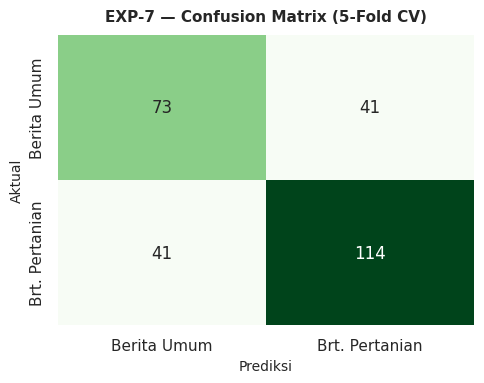

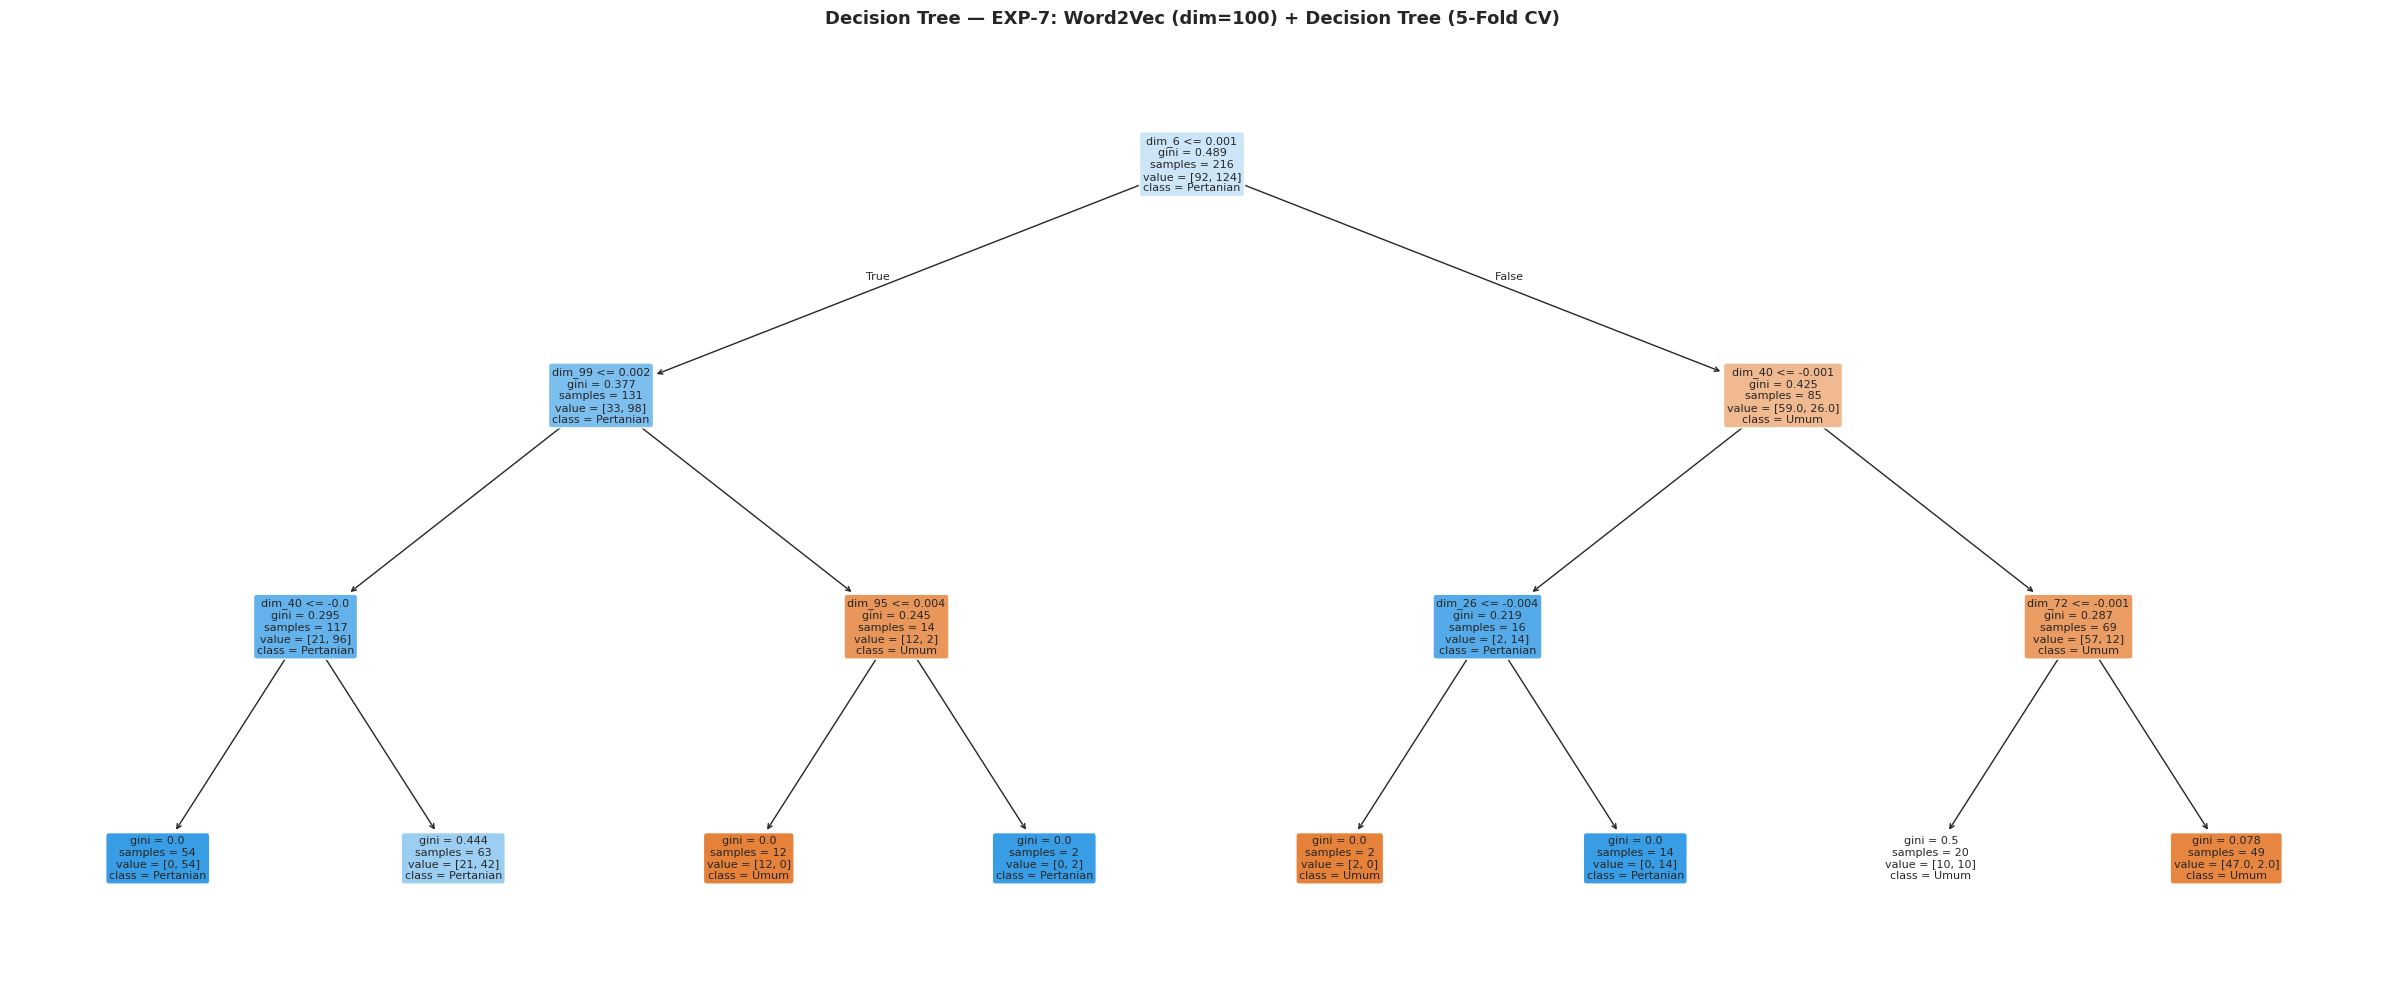

{'fit_time': array([0.06082797, 0.02724886, 0.01809955, 0.01824307, 0.0199182 ]),
 'score_time': array([0.03539777, 0.01604629, 0.01553035, 0.01546383, 0.02676988]),
 'estimator': [DecisionTreeClassifier(max_depth=3, random_state=42),
  DecisionTreeClassifier(max_depth=3, random_state=42),
  DecisionTreeClassifier(max_depth=3, random_state=42),
  DecisionTreeClassifier(max_depth=3, random_state=42),
  DecisionTreeClassifier(max_depth=3, random_state=42)],
 'test_accuracy': array([0.72222222, 0.68518519, 0.68518519, 0.72222222, 0.66037736]),
 'test_precision': array([0.75      , 0.70588235, 0.81818182, 0.73529412, 0.6969697 ]),
 'test_recall': array([0.77419355, 0.77419355, 0.58064516, 0.80645161, 0.74193548]),
 'test_f1': array([0.76190476, 0.73846154, 0.67924528, 0.76923077, 0.71875   ])}

In [ ]:
# ============================================================
# EXP-7 : Word2Vec + Decision Tree
# ============================================================
EXP_ID   = 'EXP-7'
SCENARIO = 'Word2Vec (dim=100) + Decision Tree'
W2V_FEAT  = [f'dim_{i}' for i in range(VECTOR_SIZE)]

dt_w2v = DecisionTreeClassifier(max_depth=3, random_state=42)
dt_w2v.fit(X_train_w2v, y_train)
y_pred_7 = dt_w2v.predict(X_test_w2v)

# ── Bagian A: Train-Test Split ────────────────────────────────
print_split_header(EXP_ID, SCENARIO)
print_classification_report(y_test, y_pred_7)
plot_confusion_matrix(y_test, y_pred_7, EXP_ID, 'Train-Test Split 80:20')
plot_decision_tree(dt_w2v, W2V_FEAT, EXP_ID, SCENARIO, 'Train-Test Split')

# ── Bagian B: 5-Fold Cross Validation ────────────────────────
run_cv_full(
    X_all_w2v, y,
    DecisionTreeClassifier(max_depth=3, random_state=42),
    EXP_ID, SCENARIO,
    feature_names=W2V_FEAT,
    is_dt=True
)



  Tabel 6: Evaluasi EXP-8 — Word2Vec (dim=100) + Naive Bayes (Gaussian) with Train-Test Split
                      precision    recall  f1-score   support

     Berita Umum (0)     0.4545    0.4348    0.4444        23
Berita Pertanian (1)     0.5938    0.6129    0.6032        31

            accuracy                         0.5370        54
           macro avg     0.5241    0.5238    0.5238        54
        weighted avg     0.5345    0.5370    0.5356        54



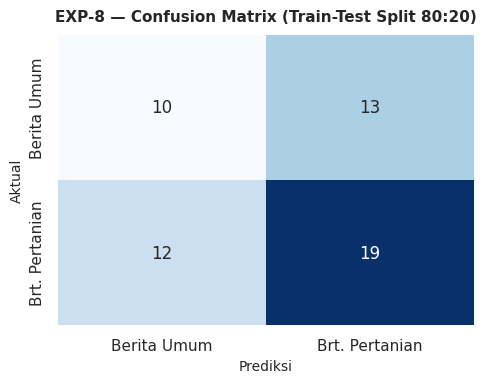


  Tabel 7: Evaluasi EXP-8 — Word2Vec (dim=100) + Naive Bayes (Gaussian) with Cross Validation
  Fold       Accuracy  Precision     Recall   F1-Score
  ------------------------------------------------------
  Fold 1       79.63%     91.67%     70.97%     80.00%
  Fold 2       88.89%     90.32%     90.32%     90.32%
  Fold 3       72.22%     80.77%     67.74%     73.68%
  Fold 4       75.93%     82.14%     74.19%     77.97%
  Fold 5       75.47%     82.14%     74.19%     77.97%
  ------------------------------------------------------
  Mean         78.43%     85.41%     75.48%     79.99%
  Std           5.73%      4.61%      7.80%      5.56%

📊 Confusion Matrix (Akumulasi 5-Fold CV):


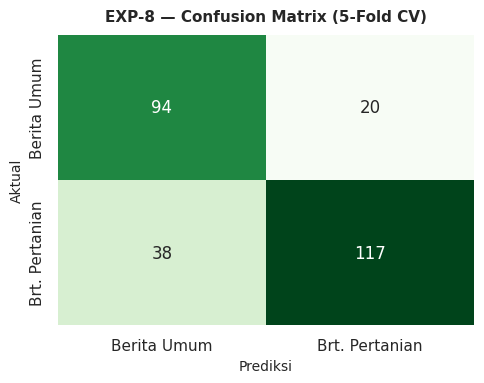

{'fit_time': array([0.0035181 , 0.0072515 , 0.00295305, 0.00293255, 0.00261831]),
 'score_time': array([0.01791024, 0.02659106, 0.02683687, 0.01376152, 0.01571727]),
 'estimator': [GaussianNB(),
  GaussianNB(),
  GaussianNB(),
  GaussianNB(),
  GaussianNB()],
 'test_accuracy': array([0.7962963 , 0.88888889, 0.72222222, 0.75925926, 0.75471698]),
 'test_precision': array([0.91666667, 0.90322581, 0.80769231, 0.82142857, 0.82142857]),
 'test_recall': array([0.70967742, 0.90322581, 0.67741935, 0.74193548, 0.74193548]),
 'test_f1': array([0.8       , 0.90322581, 0.73684211, 0.77966102, 0.77966102])}

In [ ]:
# ============================================================
# EXP-8 : Word2Vec + Naive Bayes (Gaussian)
# GaussianNB digunakan karena vektor Word2Vec bertipe float
# (bukan count/integer), tidak kompatibel dengan MultinomialNB
# ============================================================
EXP_ID   = 'EXP-8'
SCENARIO = 'Word2Vec (dim=100) + Naive Bayes (Gaussian)'

gnb_w2v = GaussianNB()
gnb_w2v.fit(X_train_w2v, y_train)
y_pred_8 = gnb_w2v.predict(X_test_w2v)

# ── Bagian A: Train-Test Split ────────────────────────────────
print_split_header(EXP_ID, SCENARIO)
print_classification_report(y_test, y_pred_8)
plot_confusion_matrix(y_test, y_pred_8, EXP_ID, 'Train-Test Split 80:20')

# ── Bagian B: 5-Fold Cross Validation ────────────────────────
run_cv_full(
    X_all_w2v, y,
    GaussianNB(),
    EXP_ID, SCENARIO,
    is_dt=False
)



  Tabel 6: Evaluasi EXP-9 — IndoBERT (indobert-base-p2) + Decision Tree with Train-Test Split
                      precision    recall  f1-score   support

     Berita Umum (0)     0.4474    0.7391    0.5574        23
Berita Pertanian (1)     0.6250    0.3226    0.4255        31

            accuracy                         0.5000        54
           macro avg     0.5362    0.5309    0.4915        54
        weighted avg     0.5493    0.5000    0.4817        54



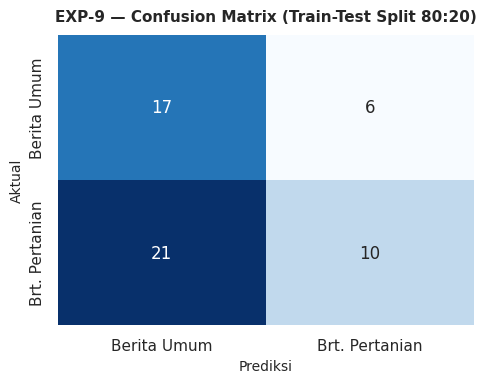

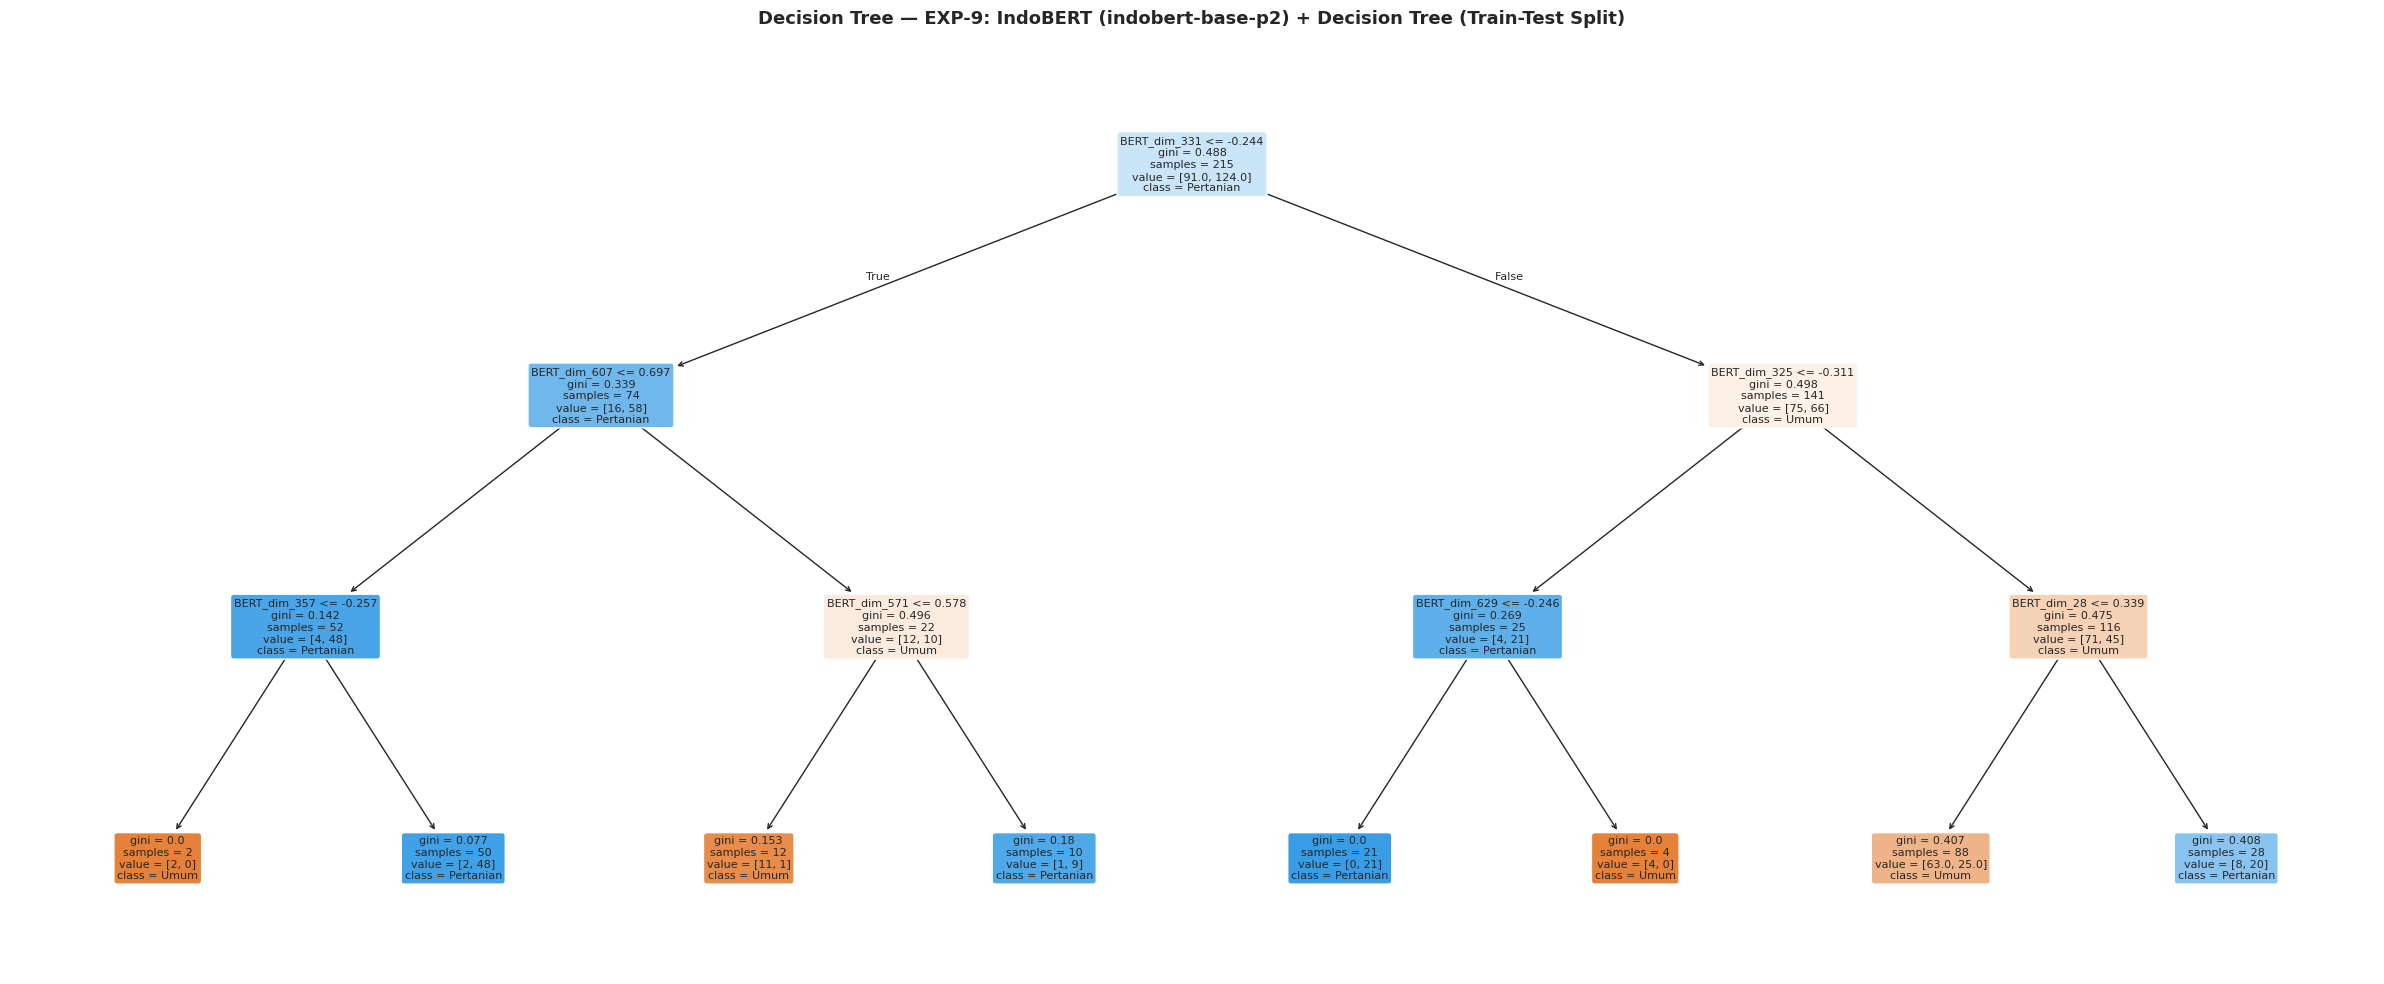


  Tabel 7: Evaluasi EXP-9 — IndoBERT (indobert-base-p2) + Decision Tree with Cross Validation
  Fold       Accuracy  Precision     Recall   F1-Score
  ------------------------------------------------------
  Fold 1       87.04%     92.86%     83.87%     88.14%
  Fold 2       77.78%     82.76%     77.42%     80.00%
  Fold 3       88.89%     87.88%     93.55%     90.62%
  Fold 4       81.48%     83.87%     83.87%     83.87%
  Fold 5       83.02%     86.67%     83.87%     85.25%
  ------------------------------------------------------
  Mean         83.64%     86.81%     84.52%     85.58%
  Std           3.96%      3.54%      5.16%      3.64%

📊 Confusion Matrix (Akumulasi 5-Fold CV):


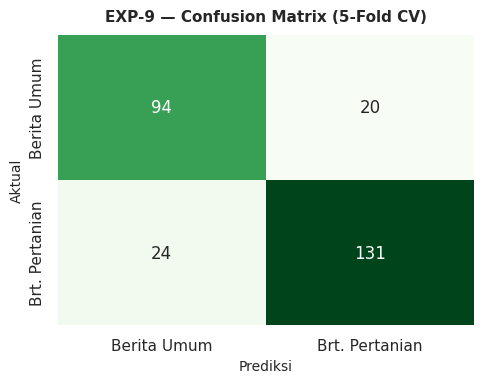

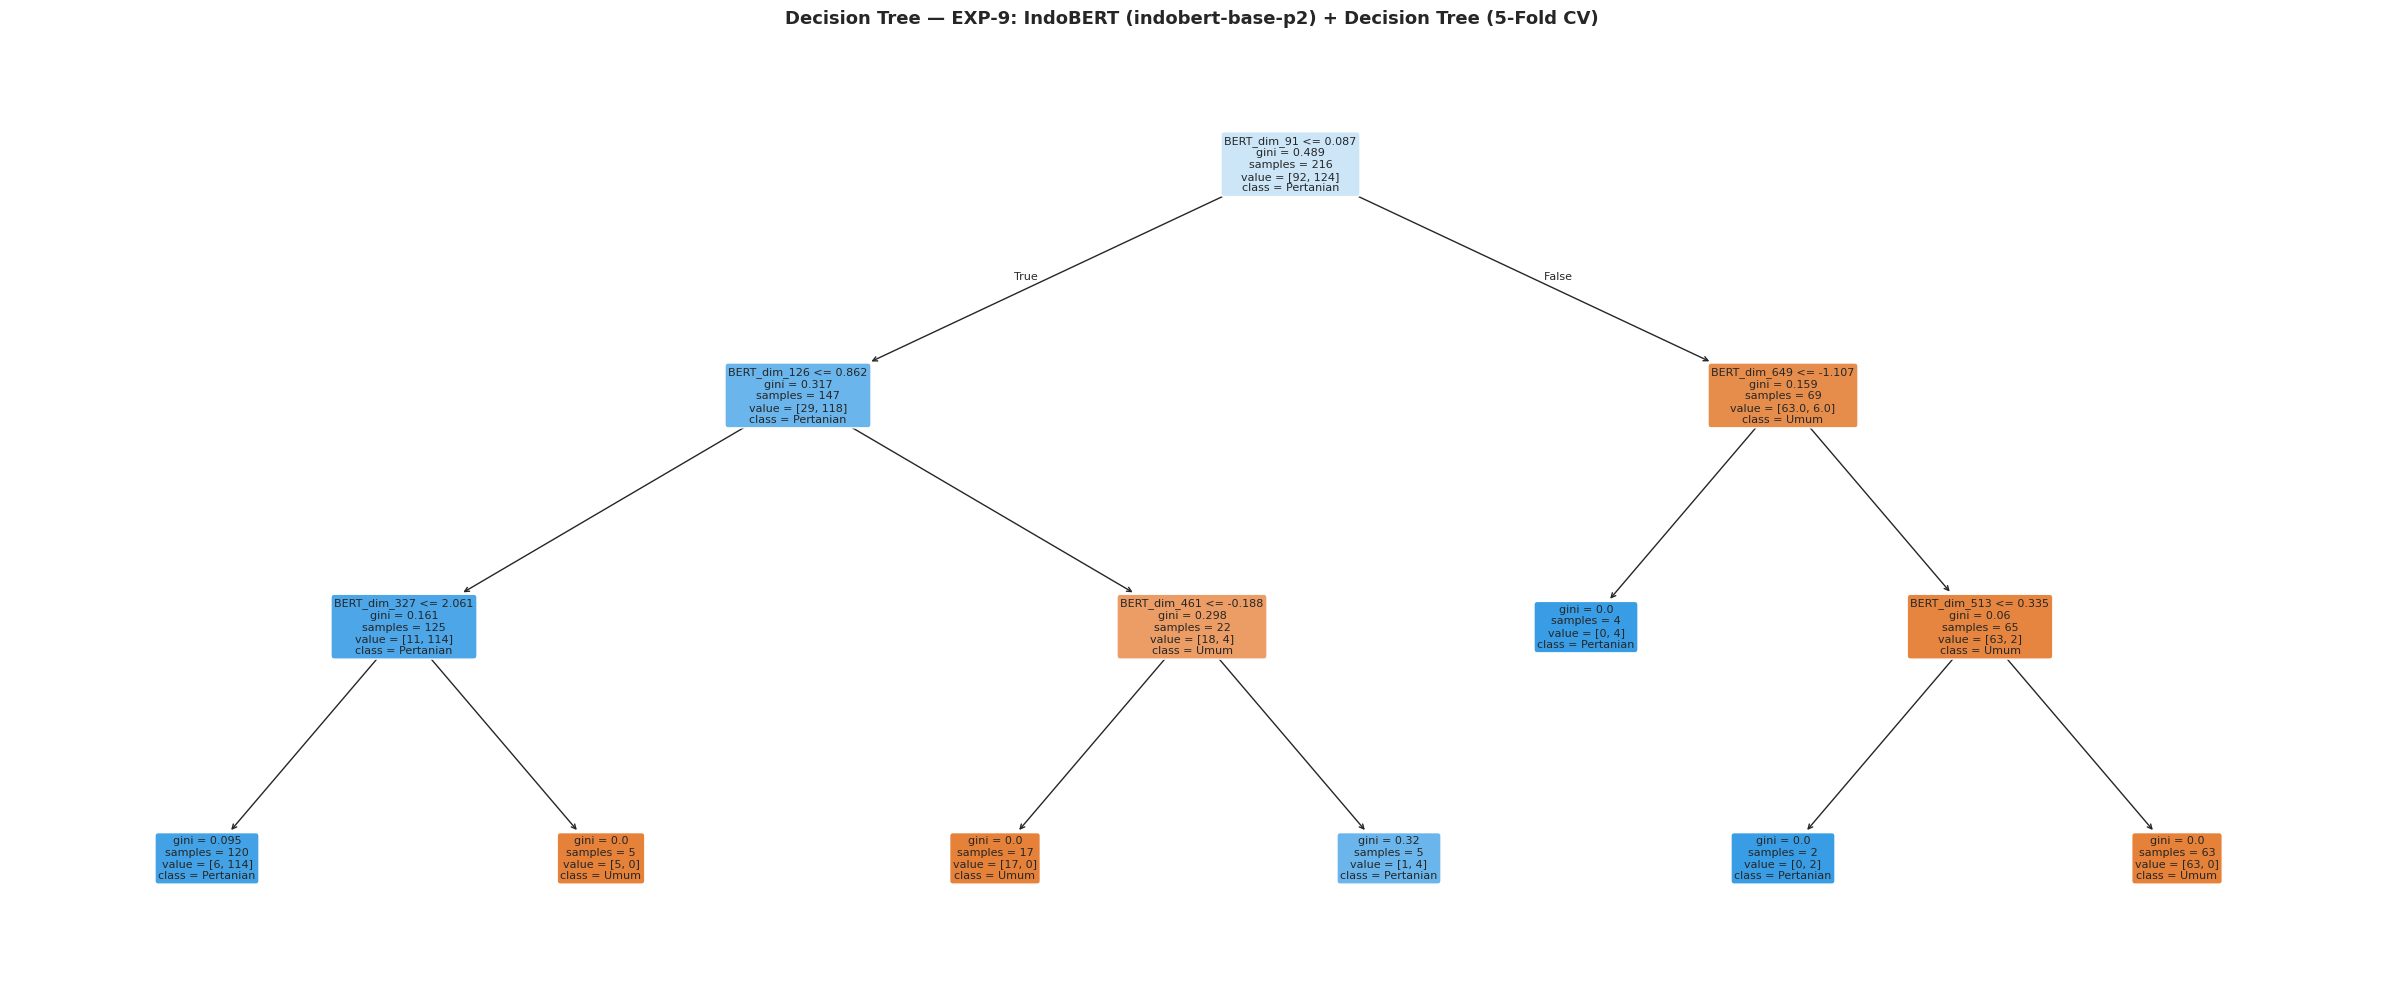

{'fit_time': array([0.15667057, 0.11836123, 0.12997103, 0.13881516, 0.11514235]),
 'score_time': array([0.01642346, 0.01638937, 0.01520181, 0.01582122, 0.01544189]),
 'estimator': [DecisionTreeClassifier(max_depth=3, random_state=42),
  DecisionTreeClassifier(max_depth=3, random_state=42),
  DecisionTreeClassifier(max_depth=3, random_state=42),
  DecisionTreeClassifier(max_depth=3, random_state=42),
  DecisionTreeClassifier(max_depth=3, random_state=42)],
 'test_accuracy': array([0.87037037, 0.77777778, 0.88888889, 0.81481481, 0.83018868]),
 'test_precision': array([0.92857143, 0.82758621, 0.87878788, 0.83870968, 0.86666667]),
 'test_recall': array([0.83870968, 0.77419355, 0.93548387, 0.83870968, 0.83870968]),
 'test_f1': array([0.88135593, 0.8       , 0.90625   , 0.83870968, 0.85245902])}

In [ ]:
# ============================================================
# EXP-9 : IndoBERT + Decision Tree
# ============================================================
EXP_ID   = 'EXP-9'
SCENARIO = 'IndoBERT (indobert-base-p2) + Decision Tree'
BERT_FEAT = [f'BERT_dim_{i}' for i in range(X_bert_all.shape[1])]

dt_bert = DecisionTreeClassifier(max_depth=3, random_state=42)
dt_bert.fit(X_train_bert, y_train)
y_pred_9 = dt_bert.predict(X_test_bert)

# ── Bagian A: Train-Test Split ────────────────────────────────
print_split_header(EXP_ID, SCENARIO)
print_classification_report(y_test, y_pred_9)
plot_confusion_matrix(y_test, y_pred_9, EXP_ID, 'Train-Test Split 80:20')
plot_decision_tree(dt_bert, BERT_FEAT, EXP_ID, SCENARIO, 'Train-Test Split')

# ── Bagian B: 5-Fold Cross Validation ────────────────────────
run_cv_full(
    X_bert_all, y_reset,
    DecisionTreeClassifier(max_depth=3, random_state=42),
    EXP_ID, SCENARIO,
    feature_names=BERT_FEAT,
    is_dt=True
)



  Tabel 6: Evaluasi EXP-10 — IndoBERT (indobert-base-p2) + Naive Bayes (Gaussian) with Train-Test Split
                      precision    recall  f1-score   support

     Berita Umum (0)     0.5263    0.4348    0.4762        23
Berita Pertanian (1)     0.6286    0.7097    0.6667        31

            accuracy                         0.5926        54
           macro avg     0.5774    0.5722    0.5714        54
        weighted avg     0.5850    0.5926    0.5855        54



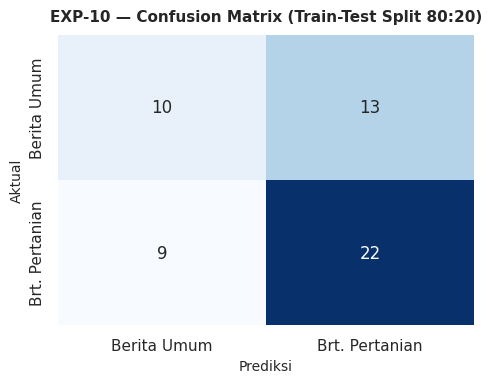


  Tabel 7: Evaluasi EXP-10 — IndoBERT (indobert-base-p2) + Naive Bayes (Gaussian) with Cross Validation
  Fold       Accuracy  Precision     Recall   F1-Score
  ------------------------------------------------------
  Fold 1       87.04%     92.86%     83.87%     88.14%
  Fold 2       88.89%     96.30%     83.87%     89.66%
  Fold 3       92.59%    100.00%     87.10%     93.10%
  Fold 4       87.04%     96.15%     80.65%     87.72%
  Fold 5       90.57%     93.33%     90.32%     91.80%
  ------------------------------------------------------
  Mean         89.22%     95.73%     85.16%     90.08%
  Std           2.14%      2.56%      3.29%      2.08%

📊 Confusion Matrix (Akumulasi 5-Fold CV):


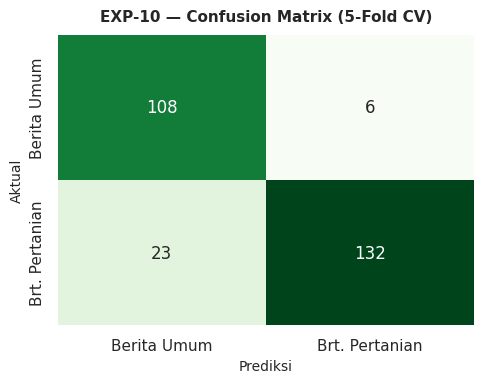

{'fit_time': array([0.0114665 , 0.00887847, 0.00659728, 0.0047791 , 0.02372599]),
 'score_time': array([0.02492285, 0.03721786, 0.0185082 , 0.01515818, 0.06059361]),
 'estimator': [GaussianNB(),
  GaussianNB(),
  GaussianNB(),
  GaussianNB(),
  GaussianNB()],
 'test_accuracy': array([0.87037037, 0.88888889, 0.92592593, 0.87037037, 0.90566038]),
 'test_precision': array([0.92857143, 0.96296296, 1.        , 0.96153846, 0.93333333]),
 'test_recall': array([0.83870968, 0.83870968, 0.87096774, 0.80645161, 0.90322581]),
 'test_f1': array([0.88135593, 0.89655172, 0.93103448, 0.87719298, 0.91803279])}

In [ ]:
# ============================================================
# EXP-10 : IndoBERT + Naive Bayes (Gaussian)
# ============================================================
EXP_ID   = 'EXP-10'
SCENARIO = 'IndoBERT (indobert-base-p2) + Naive Bayes (Gaussian)'

gnb_bert = GaussianNB()
gnb_bert.fit(X_train_bert, y_train)
y_pred_10 = gnb_bert.predict(X_test_bert)

# ── Bagian A: Train-Test Split ────────────────────────────────
print_split_header(EXP_ID, SCENARIO)
print_classification_report(y_test, y_pred_10)
plot_confusion_matrix(y_test, y_pred_10, EXP_ID, 'Train-Test Split 80:20')

# ── Bagian B: 5-Fold Cross Validation ────────────────────────
run_cv_full(
    X_bert_all, y_reset,
    GaussianNB(),
    EXP_ID, SCENARIO,
    is_dt=False
)


=== TABEL REKAPITULASI 10 SKENARIO ===
    ID                           Skenario  Akurasi  Precision  Recall  F1-Score
 EXP-1                BoW + Decision Tree    87.04      81.58  100.00     89.86
 EXP-2    BoW + Naive Bayes (Multinomial)    92.59      90.91   96.77     93.75
 EXP-3             N-Gram + Decision Tree    87.04      81.58  100.00     89.86
 EXP-4 N-Gram + Naive Bayes (Multinomial)    92.59      90.91   96.77     93.75
 EXP-5             TF-IDF + Decision Tree    87.04      81.58  100.00     89.86
 EXP-6 TF-IDF + Naive Bayes (Multinomial)    88.89      85.71   96.77     90.91
 EXP-7           Word2Vec + Decision Tree    38.89      46.43   41.94     44.07
 EXP-8  Word2Vec + Naive Bayes (Gaussian)    53.70      59.38   61.29     60.32
 EXP-9           IndoBERT + Decision Tree    50.00      62.50   32.26     42.55
EXP-10  IndoBERT + Naive Bayes (Gaussian)    59.26      62.86   70.97     66.67


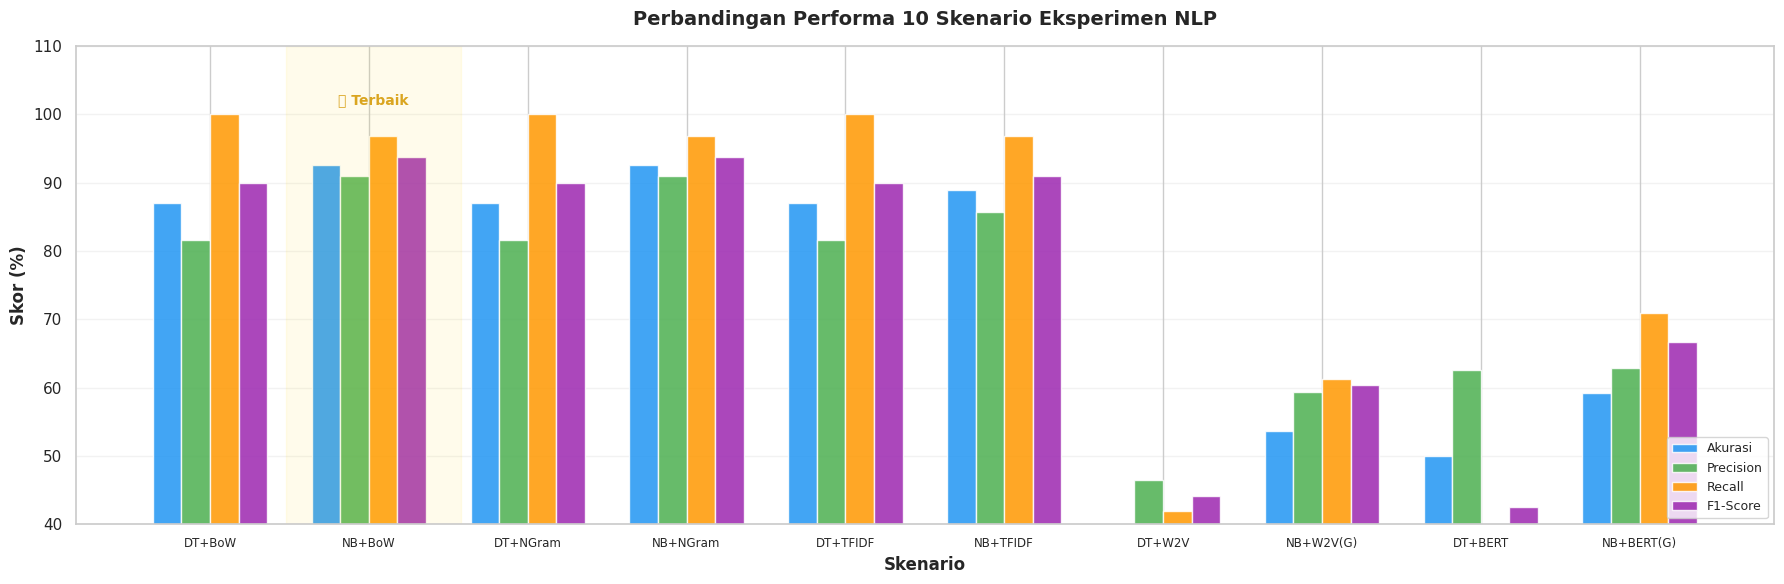

In [ ]:
# ============================================================
# REKAPITULASI PERFORMA + SIMPAN ARTIFACT DASHBOARD
# ============================================================
configs_eval = [
    ('EXP-1',  'BoW + Decision Tree',                'bow',      'DecisionTreeClassifier', vec_bow,   X_test_bow,   dt_bow,   'bow'),
    ('EXP-2',  'BoW + Naive Bayes (Multinomial)',    'bow',      'MultinomialNB',          vec_bow,   X_test_bow,   nb_bow,   'bow'),
    ('EXP-3',  'N-Gram + Decision Tree',             'ngram',    'DecisionTreeClassifier', vec_ngram, X_test_ngram, dt_ngram, 'ngram'),
    ('EXP-4',  'N-Gram + Naive Bayes (Multinomial)', 'ngram',    'MultinomialNB',          vec_ngram, X_test_ngram, nb_ngram, 'ngram'),
    ('EXP-5',  'TF-IDF + Decision Tree',             'tfidf',    'DecisionTreeClassifier', vec_tfidf, X_test_tfidf, dt_tfidf, 'tfidf'),
    ('EXP-6',  'TF-IDF + Naive Bayes (Multinomial)', 'tfidf',    'MultinomialNB',          vec_tfidf, X_test_tfidf, nb_tfidf, 'tfidf'),
    ('EXP-7',  'Word2Vec + Decision Tree',           'word2vec', 'DecisionTreeClassifier', None,      X_test_w2v,   dt_w2v,   None),
    ('EXP-8',  'Word2Vec + Naive Bayes (Gaussian)',  'word2vec', 'GaussianNB',              None,      X_test_w2v,   gnb_w2v,  None),
    ('EXP-9',  'IndoBERT + Decision Tree',           'bert',     'DecisionTreeClassifier', None,      X_test_bert,  dt_bert,  None),
    ('EXP-10', 'IndoBERT + Naive Bayes (Gaussian)',  'bert',     'GaussianNB',              None,      X_test_bert,  gnb_bert, None),
]

def metric_payload(y_true, y_pred):
    labels_order = [1, 0]
    precision_values, recall_values, f1_values, support_values = precision_recall_fscore_support(
        y_true, y_pred, labels=labels_order, zero_division=0
    )
    cm = confusion_matrix(y_true, y_pred, labels=labels_order)
    return {
        'accuracy': float(accuracy_score(y_true, y_pred)),
        'precision': float(precision_score(y_true, y_pred, zero_division=0)),
        'recall': float(recall_score(y_true, y_pred, zero_division=0)),
        'f1': float(f1_score(y_true, y_pred, zero_division=0)),
        'confusion': {
            'tp': int(cm[0][0]),
            'fn': int(cm[0][1]),
            'fp': int(cm[1][0]),
            'tn': int(cm[1][1]),
        },
        'per_class': [
            {
                'label': int(label),
                'precision': float(precision_values[index]),
                'recall': float(recall_values[index]),
                'f1': float(f1_values[index]),
                'support': int(support_values[index]),
            }
            for index, label in enumerate(labels_order)
        ]
    }

all_results = []
results = {}
models = {}
for exp_id, scenario, feature_type, classifier_name, vectorizer, X_t, estimator, vectorizer_key in configs_eval:
    y_p = estimator.predict(X_t)
    metrics = metric_payload(y_test, y_p)
    results[exp_id] = metrics
    models[exp_id] = {
        'scenario': scenario,
        'feature_type': feature_type,
        'classifier': classifier_name,
        'vectorizer_key': vectorizer_key,
        'estimator': estimator,
    }
    all_results.append({
        'ID': exp_id,
        'Skenario': scenario,
        'Akurasi': round(metrics['accuracy'] * 100, 2),
        'Precision': round(metrics['precision'] * 100, 2),
        'Recall': round(metrics['recall'] * 100, 2),
        'F1-Score': round(metrics['f1'] * 100, 2),
    })

df_all = pd.DataFrame(all_results)
best_row = df_all.sort_values(['F1-Score', 'Akurasi'], ascending=False).iloc[0]
best_model_id = best_row['ID']

print('=== TABEL REKAPITULASI 10 SKENARIO ===')
print(df_all.to_string(index=False))
print(f'\nModel terbaik berdasarkan F1-Score: {best_model_id} — {best_row["Skenario"]}')

os.makedirs('artifacts/models', exist_ok=True)
artifact_bundle = {
    'created_by': 'NLP_10_Skenario_Final.ipynb',
    'dataset': FILE_NAME,
    'bert_model_name': MODEL_NAME,
    'best_model_id': best_model_id,
    'split': {
        'random_state': 42,
        'test_size': 0.2,
        'train_size': int(len(y_train)),
        'test_size_rows': int(len(y_test)),
        'train_index': [int(i) for i in X_train_raw.index.tolist()],
        'test_index': [int(i) for i in X_test_raw.index.tolist()],
    },
    'vectorizers': {
        'bow': vec_bow,
        'ngram': vec_ngram,
        'tfidf': vec_tfidf,
    },
    'word2vec': model_w2v,
    'word2vec_vector_size': VECTOR_SIZE,
    'bert_embeddings': X_bert_all,
    'models': models,
    'results': results,
    'results_table': df_all.to_dict(orient='records'),
    'class_labels': {0: 'Bukan Pertanian', 1: 'Berita Pertanian'},
    'preprocessing': {
        'lowercase': True,
        'regex': r'[^a-z\s]',
        'stopwords': 'nltk english',
        'stemmer': 'PorterStemmer',
    },
}

artifact_path = 'artifacts/agri_nlp_experiments.joblib'
joblib.dump(artifact_bundle, artifact_path)
for exp_id, model_data in models.items():
    joblib.dump(model_data, f'artifacts/models/{exp_id}.joblib')

# Legacy single-file export: keeps older scripts usable while dashboard uses artifact_bundle.
best_model_data = models[best_model_id]
joblib.dump(best_model_data, 'model_pertanian.pkl')
df_all.to_csv('artifacts/experiment_results.csv', index=False)

print(f'✅ Artifact utama tersimpan: {artifact_path}')
print('✅ Model per skenario tersimpan: artifacts/models/EXP-*.joblib')
print('✅ Rekap metrik tersimpan: artifacts/experiment_results.csv')

# ── Bar Chart Perbandingan ────────────────────────────────────
metrics_list = ['Akurasi', 'Precision', 'Recall', 'F1-Score']
bar_colors   = ['#2196F3', '#4CAF50', '#FF9800', '#9C27B0']
shorts       = ['DT+BoW', 'NB+BoW', 'DT+NGram', 'NB+NGram',
                'DT+TFIDF', 'NB+TFIDF', 'DT+W2V', 'NB+W2V(G)',
                'DT+BERT', 'NB+BERT(G)']

best_i = df_all['F1-Score'].idxmax()
x      = np.arange(len(df_all))
width  = 0.18

fig, ax = plt.subplots(figsize=(18, 6))
for i, (metric, color) in enumerate(zip(metrics_list, bar_colors)):
    ax.bar(x + i * width, df_all[metric], width,
           label=metric, color=color, alpha=0.85)

ax.axvspan(best_i - 0.25, best_i + 0.85, alpha=0.08, color='gold')
ax.text(best_i + 0.3, df_all[metrics_list].max().max() + 1.5,
        'Terbaik', ha='center', fontweight='bold', color='goldenrod', fontsize=10)
ax.set_xlabel('Skenario', fontweight='bold')
ax.set_ylabel('Skor (%)', fontweight='bold')
ax.set_title('Perbandingan Performa 10 Skenario Eksperimen NLP',
             fontsize=14, fontweight='bold', pad=15)
ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(shorts, rotation=0, fontsize=8.5)
ax.set_ylim(40, df_all[metrics_list].max().max() + 10)
ax.legend(loc='lower right', fontsize=9)
ax.grid(axis='y', alpha=0.25)
plt.tight_layout()
plt.show()
plt.close()
